<a href="https://colab.research.google.com/github/DanielOjados/UNIR_TFM/blob/main/notebooks/01_eda_calidad_fiabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA, calidad y fiabilidad del dataset

Notebook definitivo con analisis EDA para el TFM.

## Fuentes oficiales de datos

Este notebook queda preparado para consumir las fuentes definitivas del proyecto en Google Cloud. El dataset final de modelado se lee desde BigQuery: `project-bucephalus.baseline_v5final.baseline`. Los datos raw se leen desde Google Cloud Storage: `gs://bucephalus-bucket1/datasets_raw`. Todos los ficheros raw se tratan como CSV salvo `caballos_con_ids_progenitores`, que se carga como Excel (`.xlsx`).

La lectura local se conserva únicamente como mecanismo de contingencia para entornos sin credenciales de Google Cloud, pero no constituye la fuente canónica del TFM.


In [ ]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd

BQ_PROJECT = 'project-bucephalus'
BQ_DATASET = 'baseline_v5final'
BQ_TABLE   = 'baseline'
BQ_FULL_TABLE = f'{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}'

GCS_BUCKET = 'bucephalus-bucket1'
GCS_RAW_PREFIX = 'datasets_raw'
GCS_RAW_URI = f'gs://{GCS_BUCKET}/{GCS_RAW_PREFIX}'

USE_BIGQUERY = True
ALLOW_LOCAL_FALLBACK = True
LOCAL_PROCESSED = Path('../data/processed')
LOCAL_RAW = Path('../data/raw')

DATE_COL = 'fecha'
RACE_ID_COL = 'race_id'
HORSE_ID_COL = 'caballo_id'
TARGET_COL = 'target_top3'
WIN_TARGET_COL = 'target_top1'
POSITION_COL = 'pos'


def load_final_dataset(use_bigquery: bool = USE_BIGQUERY) -> pd.DataFrame:
    """Carga el dataset final desde BigQuery y, solo si se permite, cae a parquet local."""
    if use_bigquery:
        try:
            from google.cloud import bigquery
            client = bigquery.Client(project=BQ_PROJECT)
            query = f"SELECT * FROM `{BQ_FULL_TABLE}`"
            df = client.query(query).to_dataframe(create_bqstorage_client=True)
            print(f'BigQuery: {BQ_FULL_TABLE} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
        except Exception as exc:
            if not ALLOW_LOCAL_FALLBACK:
                raise
            print(f'AVISO: no se pudo leer BigQuery ({exc}). Se usará parquet local como contingencia.')
    candidates = [
        LOCAL_PROCESSED / 'master_v5_final.parquet',
        Path('/home/ubuntu/Proyecto-Bucephalus/data/processed/master_v5_final.parquet'),
        Path('/home/ubuntu/upload/master_v5_final.parquet'),
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_parquet(path)
            print(f'Parquet local de contingencia: {path} -> {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
            return df
    raise FileNotFoundError('No se pudo cargar el dataset final ni desde BigQuery ni desde parquet local.')


def gcs_raw_path(filename: str) -> str:
    return f'{GCS_RAW_URI}/{filename}'


def load_raw_dataset(stem_or_filename: str, **kwargs) -> pd.DataFrame:
    """Carga un raw desde GCS. `caballos_con_ids_progenitores` se fuerza a Excel."""
    name = stem_or_filename
    lower = name.lower()
    if 'caballos_con_ids_progenitores' in lower:
        if not lower.endswith(('.xlsx', '.xls')):
            name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.xlsx'
        path = gcs_raw_path(name)
        return pd.read_excel(path, **kwargs)
    if not lower.endswith('.csv'):
        name = re.sub(r'\.(csv|parquet|xlsx|xls)$', '', name, flags=re.I) + '.csv'
    path = gcs_raw_path(name)
    return pd.read_csv(path, **kwargs)


def prepare_modelable_dataset(df: pd.DataFrame, min_field_size: int = 3) -> pd.DataFrame:
    '''Aplica los filtros canónicos del dataset definitivo del TFM.'''
    out = df.copy()
    if 'fecha' in out.columns:
        # Ensure 'fecha' is a datetime object. It might be timezone-aware (e.g., UTC) from BigQuery.
        out['fecha'] = pd.to_datetime(out['fecha'], errors='coerce')

    if 'carrera_id' in out.columns:
        out = out[pd.to_numeric(out['carrera_id'], errors='coerce') <= 11926]

    if 'fecha' in out.columns:
        # The 'fecha' column is datetime64[us, UTC]. To avoid TypeError, ensure comparison dates are also UTC-aware.
        start_date_aware = pd.to_datetime('1990-01-01', utc=True)
        end_date_aware = pd.to_datetime('2025-12-31', utc=True)
        out = out[out['fecha'].between(start_date_aware, end_date_aware)]
    if 'target_top3' not in out.columns and 'pos' in out.columns:
        pos = pd.to_numeric(out['pos'], errors='coerce')
        valid = pos.notna() & (pos > 0) & (pos < 90)
        out['target_top1'] = (valid & (pos == 1)).astype(int)
        out['target_top3'] = (valid & (pos <= 3)).astype(int)
    group_col = 'race_id' if 'race_id' in out.columns else 'carrera_id'
    if group_col in out.columns:
        sizes = out.groupby(group_col)[group_col].transform('size')
        out = out[sizes >= min_field_size]
    return out.reset_index(drop=True)


def temporal_split(df: pd.DataFrame, train_end: str = '2023-12-31', val_end: str = '2024-09-30'):
    '''Split cronológico final: test contiene carreras posteriores hasta `carrera_id <= 11926`.'''
    out = prepare_modelable_dataset(df)
    out = out.sort_values(['fecha', 'carrera_id', 'caballo_id'], na_position='last').reset_index(drop=True)
    train = out[out['fecha'] <= pd.Timestamp(train_end)].copy()
    val = out[(out['fecha'] > pd.Timestamp(train_end)) & (out['fecha'] <= pd.Timestamp(val_end))].copy()
    test = out[out['fecha'] > pd.Timestamp(val_end)].copy()
    if 'carrera_id' in test.columns:
        assert pd.to_numeric(test['carrera_id'], errors='coerce').max() <= 11926
    return train, val, test

# Política de variables post-carrera / cuarentena metodológica
# -----------------------------------------------------------
# `pos` es la etiqueta bruta de llegada; solo se usa para construir targets y auditoría.
# `distancia_al_anterior` y variantes (`dist_al_anterior`) solo existen después de la carrera.
# `odds_win`/`dividendo_ganador` se reserva para baseline de mercado o ROI, nunca para el modelo científico principal.
POST_RACE_COLS = {
    'pos', 'target_top1', 'target_top3', 'target_pos', 'target_rank_label',
    'distancia_al_anterior', 'dist_al_anterior', 'race_has_winner',
    'odds_win', 'dividendo_ganador', 'dividendo_colocado', 'payout_win'
}
IDENTIFIER_COLS = {
    'carrera_id', 'race_id', 'caballo_id', 'jinete_id', 'preparador_id',
    'padre_id', 'madre_id', 'abuelo_id', 'criador_id', 'jornada_id'
}
TEXT_COLS = {
    'nombre', 'caballo_nombre', 'jinete_nombre', 'preparador_nombre',
    'hipodromo', 'carrera_nombre', 'condiciones', 'padre___madre', 'pista'
}
DATE_COLS = {'fecha'}

def get_feature_columns(df: pd.DataFrame, include_odds: bool = False, include_quarantine: bool = False) -> list[str]:
    '''Devuelve features numéricas conocidas antes de la salida de la carrera.

    Por defecto excluye variables post-carrera, identificadores puros, textos y targets.
    `include_odds=True` solo debe usarse en notebooks de ROI o baseline de mercado.
    '''
    quarantine = set()
    if not include_quarantine:
        quarantine |= set(POST_RACE_COLS)
    if include_odds:
        quarantine -= {'odds_win'}
    else:
        quarantine |= {'odds_win'}
    exclude = quarantine | IDENTIFIER_COLS | TEXT_COLS | DATE_COLS
    exclude |= {c for c in df.columns if c.startswith('target_')}
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c]):
            cols.append(c)
    forbidden = sorted((set(cols) & set(POST_RACE_COLS)) - ({'odds_win'} if include_odds else set()))
    if forbidden:
        raise ValueError(f'Features con leakage detectadas: {forbidden}')
    return cols

# Auditoría, EDA y Preprocesamiento

**Versión científica reproducible**

Este cuaderno realiza:
1. **Auditoría de integridad temporal** del dataset (orden, anomalías, cobertura)
2. **Auditoría de leakage** (filtración de información del futuro)
3. **Definición rigurosa del esquema de splits** (cronológico por fecha)
4. **Análisis exploratorio** (EDA) profundo
5. **Detección de covariate shift** entre splits
6. **Preprocesamiento reproducible** con artefactos versionados

## Decisiones metodológicas

| Decisión | Justificación |
|---|---|
| **Excluir `carrera_id > 11926`** | Carreras sin posición final registrada → no usables para entrenamiento supervisado |
| **Excluir fechas anómalas anteriores a 1990** | fechas anómalas anteriores a los años noventa rompen la asunción de que `carrera_id` ≈ orden cronológico (Spearman ρ = 0.86 → 0.58 en el bloque alto) |
| **Split por FECHA, no por `carrera_id`** | El identificador `carrera_id` no es estrictamente monotónico en fecha; un split por ID fugaría carreras del s.XIX en val/test |
| **Cronológico 70/20/10** | Walk-forward holdout — refleja el caso de uso real (predecir el futuro) |
| **Variables post-carrera excluidas** | `pos`, `distancia_al_anterior`/`dist_al_anterior`, `target_*`, `race_has_winner`; `odds_win` solo se admite en baseline de mercado/ROI |

**Referencias metodológicas**: Bergmeir & Benítez (2012) *On the use of cross-validation for time series predictor evaluation*; Roberts et al. (2017) *Cross-validation strategies for data with temporal, spatial, hierarchical or phylogenetic structure*.


In [ ]:
import sys, os, warnings, json, pickle, hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import (mannwhitneyu, pointbiserialr, spearmanr,
                          ks_2samp, chi2_contingency)
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 4.5),
                      'axes.titlesize': 12, 'axes.labelsize': 11})

ROOT = Path(os.getcwd())
if ROOT.name == 'notebooks': ROOT = ROOT.parent
PROCESSED = ROOT / 'data' / 'processed'
REPORTS   = ROOT / 'data' / 'reports'
MODELS_DIR = ROOT / 'data' / 'models'
PROCESSED.mkdir(parents=True, exist_ok=True) # Added this line
REPORTS.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

#try:
#    from google.colab import drive
#    DRIVE = Path('/content/drive/MyDrive/Bucephalus')
#    if not DRIVE.exists(): drive.mount('/content/drive', force_remount=False)
#    if DRIVE.exists(): PROCESSED = DRIVE / 'data' / 'processed'
#except ImportError: pass

RNG_SEED = 42
np.random.seed(RNG_SEED)
print(f'NumPy:  {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'PROCESSED: {PROCESSED}')
print(f'Run timestamp: {datetime.now().isoformat(timespec="seconds")}')

NumPy:  2.0.2
Pandas: 2.2.2
PROCESSED: /content/data/processed
Run timestamp: 2026-05-26T09:33:38


---
## 1. Auditoría de Integridad del Dataset

Antes de cualquier análisis, verificamos las propiedades fundamentales:
1. ¿Es `carrera_id` monotónico en `fecha`? (necesario si fuese a usarse para split)
2. ¿Hay carreras con `pos` no registrada? (imposible aprender de ellas)
3. ¿Hay anomalías de fechas (outliers temporales)?

In [ ]:
# Lectura canónica del dataset final desde BigQuery
df = load_final_dataset()
df = prepare_modelable_dataset(df)
print(df.shape)
display(df.head())


BigQuery: project-bucephalus.baseline_v5final.baseline -> 101,976 filas x 215 columnas
(101958, 215)


,carrera_id,casilla,caballo_id,peso,jinete_id,preparador_id,jornada_id,numero,carrera_nombre,condiciones,participantes_programa,distancia,pista,fecha,hipodromo,num_carreras,num_participantes,distancia_m,pista_recta,jinete_nombre,preparador_nombre,caballo,target_top1,target_top3,target_pos,target_rank_label,race_has_winner,horse_n_prev_races,horse_cum_earnings,horse_rest_days,horse_win_rate_cum,horse_top3_rate_cum,horse_avg_pos_cum,horse_avg_pos_roll3,horse_pos_std_roll3,horse_earnings_roll3,horse_win_rate_roll3,horse_top3_rate_roll3,horse_avg_pos_roll5,horse_pos_std_roll5,...,padre___madre,horse_median_pos_roll3,horse_median_pos_roll5,horse_median_pos_roll10,horse_days_since_last_win,horse_consecutive_top3,horse_consecutive_win,horse_ewm_pos_span5,horse_ewm_win_span5,horse_ewm_pos_span10,horse_ewm_win_span10,peso_delta,wr_peso_delta_race_zscore,horse_hipo_win_rate_cum,horse_hipo_win_rate_roll5,horse_hipo_win_rate_roll10,horse_dist_win_rate_cum,horse_dist_win_rate_roll5,horse_dist_win_rate_roll10,jt_win_rate_cum,jt_win_rate_roll5,jt_top3_rate_roll5,jt_win_rate_roll10,jt_top3_rate_roll10,horse_cum_wins,horse_cum_top3,jockey_cum_wins,jockey_median_pos_roll3,jockey_median_pos_roll5,jockey_median_pos_roll10,trainer_cum_wins,trainer_median_pos_roll3,trainer_median_pos_roll5,trainer_median_pos_roll10,weather_temp_max,weather_temp_min,weather_precip_mm,weather_windspeed_max,weather_sunshine_h,weather_going
0,2743,NaN,7262,62.0000,319,<NA>,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.0000,False,Sr.Martínez R.,-,metropolitano,1,1,1,3,1,14,15360.0000,623.0000,0.1429,0.6429,4.7857,3.3333,1.5275,2160.0000,0.0000,0.6667,2.6000,1.5166,...,shaadi,3.0000,2.0000,2.0000,658.0000,1,0,2.8157,0.1078,3.1289,0.1378,6.0000,1.1119,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,2.0000,9.0000,31.0000,1.0000,1.0000,1.5000,6.0000,4.0000,4.0000,4.0000,12.9000,8.4000,11.0000,18.9000,11.6453,2.0000
1,2743,NaN,688,60.0000,338,193,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.0000,False,Srta.Varela M.,M.Alonso,jackson,0,1,2,2,1,31,3265.0000,252.0000,0.0323,0.2903,4.8065,5.0000,2.0000,840.0000,0.0000,0.3333,4.2000,1.7889,...,crystal palace,5.0000,3.0000,4.0000,1365.0000,0,0,4.8993,0.0003,4.7655,0.0060,1.0000,-0.5153,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,1.0000,9.0000,5.0000,5.0000,5.0000,4.5000,10.0000,8.0000,5.0000,5.5000,12.9000,8.4000,11.0000,18.9000,11.6453,2.0000
2,2743,NaN,7027,62.0000,356,196,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.0000,False,Sr.Sarabia D.A.,J.C.Fernández R.,king town,0,1,3,1,1,6,1075.0000,119.0000,0.0000,0.0000,8.0000,7.3333,3.0551,1075.0000,0.0000,0.0000,7.8000,2.4900,...,assert,8.0000,8.0000,8.5000,NaN,0,0,7.0556,0.0000,7.5722,0.0000,0.5000,-0.6780,NaN,NaN,NaN,NaN,NaN,NaN,0.0444,0.2000,0.4000,0.1000,0.2000,0.0000,0.0000,17.0000,1.0000,1.0000,2.0000,30.0000,8.0000,8.0000,8.5000,12.9000,8.4000,11.0000,18.9000,11.6453,2.0000
3,2743,NaN,6013,60.0000,<NA>,76,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.0000,False,None,A.Carrasco,campogredos,0,0,4,0,1,21,4160.0000,651.0000,0.0000,0.2857,5.5238,4.6667,1.1547,500.0000,0.0000,0.0000,3.8000,1.4832,...,rheffissimo,4.0000,4.0000,4.0000,NaN,0,0,4.5681,0.0000,4.7134,0.0000,1.0000,-0.5153,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,6.0000,1.0000,6.0000,5.0000,6.0000,1.0000,4.0000,5.0000,5.0000,12.9000,8.4000,11.0000,18.9000,11.6453,2.0000
4,2743,NaN,355,58.0000,357,194,640,2005-140,P.A.E.G.R.I.,4a.,6,2400,a,2005-05-15 00:00:00+00:00,ANT,4,32,2400.0000,False,Sr.Lezama A.,A.Sarabia,flip the coin,0,0,5,0,1,14,2370.0000,7.0000,0.0000,0.2143,7.2143,6.6667,3.2146,200.0000,0.0000,0.3333,6.4000,2.3022,...,ocarina,8.0000,6.0000,8.0000,NaN,1,0,6.1473,0.0000,6.6988,0.0000,0.0000,-0.8407,NaN,NaN,NaN,NaN,NaN,NaN,0.0870,0.0000,0.6000,0.0000,0.5000,0.0000,3.0000,2.0000,4.0000,4.0000,4.0000,25.0000,5.0000,5.0000,4.5000,12.9000,8.4000,11.0000,

In [ ]:
# ── 1.2 ¿Es carrera_id monotónico en fecha? ───────────────────────────
race_first = df.groupby('carrera_id')['fecha'].first().sort_index()
rho_global = spearmanr(race_first.index, race_first.values.astype('int64')).statistic
inversions  = (race_first.values[1:] < race_first.values[:-1]).sum()

print(f'=== TEST DE MONOTONIA carrera_id → fecha ===')
print(f'  Spearman global ρ:   {rho_global:.4f}')
print(f'  Inversiones cronológicas: {inversions} / {len(race_first)-1} ({inversions/(len(race_first)-1)*100:.2f}%)')

# ── 1.3 Spearman por bloque ────────────────────────────────────────────
blocks = [(0,2000),(2000,5000),(5000,8000),(8000,10000),(10000,12100)]
rows = []
for lo, hi in blocks:
    sub = race_first[(race_first.index >= lo) & (race_first.index < hi)]
    if len(sub) < 10: continue
    rho = spearmanr(sub.index, sub.values.astype('int64')).statistic
    rows.append({'bloque': f'{lo}-{hi}', 'n': len(sub),
                  'fecha_min': sub.min().date(), 'fecha_max': sub.max().date(),
                  'spearman': rho})
audit_df = pd.DataFrame(rows)
print('\nMonotonia carrera_id ↔ fecha por bloques:')
display(audit_df)

# ── 1.4 Distribución de fechas anómalas ────────────────────────────────
df['decade'] = (df.fecha.dt.year // 10) * 10
decade_dist = df.groupby('decade').agg(filas=('carrera_id','size'),
                                              carreras=('carrera_id','nunique'))
print('\nDistribución por década:')
display(decade_dist)

n_pre90 = df[df.fecha < '1990-01-01'].carrera_id.nunique() # Corrected df_raw to df and n_xix to n_pre90 based on print statement
print(f'\nComprobación tras depuración canónica: {n_pre90} carreras con fecha < 1990 mezcladas con IDs altos')
print(f'   → Estas carreras serían asignadas a val/test en un split por carrera_id')
print('   → Decisión aplicada en el parquet canónico: excluir fechas anómalas anteriores a 1990')


=== TEST DE MONOTONIA carrera_id → fecha ===
  Spearman global ρ:   0.9999
  Inversiones cronológicas: 89 / 11321 (0.79%)

Monotonia carrera_id ↔ fecha por bloques:


,bloque,n,fecha_min,fecha_max,spearman
0,0-2000,1815,1997-08-17,2010-08-25,0.9943
1,2000-5000,2995,2002-08-02,2009-12-27,0.9997
2,5000-8000,2963,2009-12-27,2016-10-02,1.0000
3,8000-10000,1835,2016-10-02,2021-02-21,0.9999
4,10000-12100,1714,2021-02-28,2025-04-02,1.0000



Distribución por década:


,filas,carreras
decade,,
1990,4174,412
2000,41834,4403
2010,39053,4402
2020,16897,2105



Comprobación tras depuración canónica: 0 carreras con fecha < 1990 mezcladas con IDs altos
   → Estas carreras serían asignadas a val/test en un split por carrera_id
   → Decisión aplicada en el parquet canónico: excluir fechas anómalas anteriores a 1990


---
## 2. Construcción del Dataset Limpio y Splits Temporales

In [ ]:
# ── Aplicar exclusiones y crear splits temporales ───────────────────────
df = df[(df['carrera_id'] <= 11926) & (df['fecha'] >= '1997-01-01')].copy()
df = df.sort_values(['fecha','carrera_id']).reset_index(drop=True)

n = len(df)
date_arr = df['fecha'].values
date_70 = pd.Timestamp(date_arr[int(n * 0.70)], tz='UTC')
date_90 = pd.Timestamp(date_arr[int(n * 0.90)], tz='UTC')
# Garantizar que las carreras no se parten
date_70 = df.loc[df['fecha'] >= date_70, 'fecha'].iloc[0]
date_90 = df.loc[df['fecha'] >= date_90, 'fecha'].iloc[0]

df_train = df[df['fecha'] <  date_70].copy()
df_val   = df[(df['fecha'] >= date_70) & (df['fecha'] < date_90)].copy()
df_test  = df[df['fecha'] >= date_90].copy()

# Validaciones invariantes
assert df_train.fecha.max() < df_val.fecha.min(), 'LEAKAGE: train/val overlap'
assert df_val.fecha.max()   < df_test.fecha.min(), 'LEAKAGE: val/test overlap'
assert set(df_train.carrera_id).isdisjoint(set(df_val.carrera_id))
assert set(df_val.carrera_id).isdisjoint(set(df_test.carrera_id))

splits_summary = pd.DataFrame([
    {'split':'train', 'fecha_min':df_train.fecha.min().date(), 'fecha_max':df_train.fecha.max().date(),
     'carreras':df_train.carrera_id.nunique(), 'filas':len(df_train),
     'pct_filas':100*len(df_train)/n,
     'top1_rate':df_train.target_top1.mean(), 'top3_rate':df_train.target_top3.mean()},
    {'split':'val',   'fecha_min':df_val.fecha.min().date(),   'fecha_max':df_val.fecha.max().date(),
     'carreras':df_val.carrera_id.nunique(),   'filas':len(df_val),
     'pct_filas':100*len(df_val)/n,
     'top1_rate':df_val.target_top1.mean(),    'top3_rate':df_val.target_top3.mean()},
    {'split':'test',  'fecha_min':df_test.fecha.min().date(),  'fecha_max':df_test.fecha.max().date(),
     'carreras':df_test.carrera_id.nunique(),  'filas':len(df_test),
     'pct_filas':100*len(df_test)/n,
     'top1_rate':df_test.target_top1.mean(),   'top3_rate':df_test.target_top3.mean()},
])
print('=== SPLIT TEMPORAL DEFINITIVO ===')
display(splits_summary.style.format({'pct_filas':'{:.1f}%','top1_rate':'{:.4f}','top3_rate':'{:.4f}'}))

# Guardar parquets
df.to_parquet(PROCESSED / 'master_clean.parquet', index=False)
df_train.to_parquet(PROCESSED / 'split_train_temporal.parquet', index=False)
df_val.to_parquet(PROCESSED / 'split_val_temporal.parquet',   index=False)
df_test.to_parquet(PROCESSED / 'split_test_temporal.parquet', index=False)
splits_summary.to_csv(REPORTS / 'splits_summary.csv', index=False)
print('\nParquets guardados.')

=== SPLIT TEMPORAL DEFINITIVO ===


,split,fecha_min,fecha_max,carreras,filas,pct_filas,top1_rate,top3_rate
0,train,1997-08-17,2016-07-03,7641,71336,70.0%,0.1073,0.3214
1,val,2016-07-07,2022-01-23,2395,20414,20.0%,0.1176,0.3518
2,test,2022-01-30,2025-04-02,1286,10208,10.0%,0.1261,0.3780



Parquets guardados.


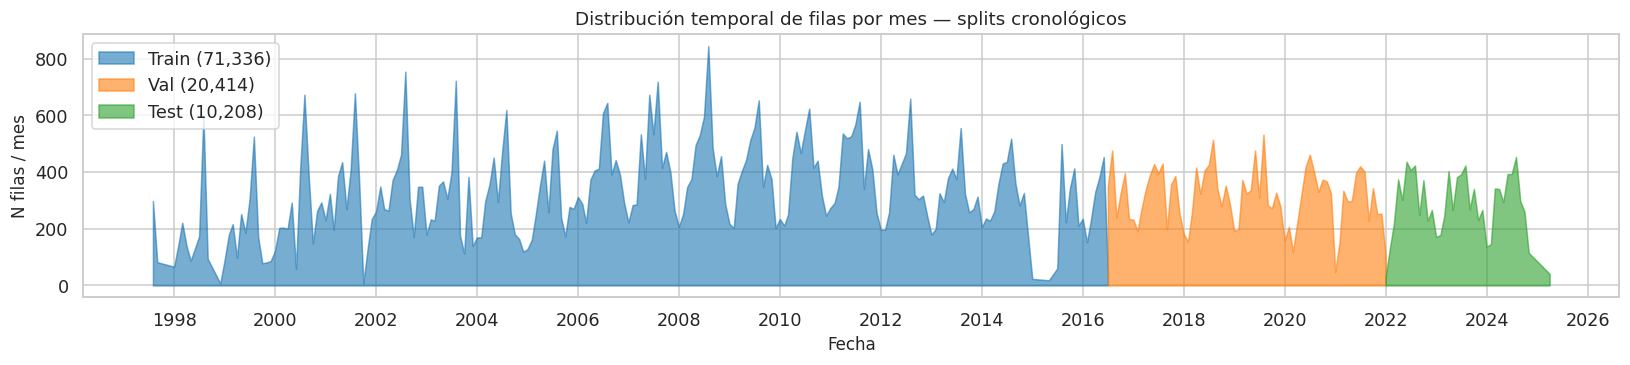

In [ ]:
# ── Visualización temporal de los splits ────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 3.5))
for sp_name, sp_df, color in [('Train', df_train, '#1f77b4'),
                                ('Val',   df_val,   '#ff7f0e'),
                                ('Test',  df_test,  '#2ca02c')]:
    by_month = sp_df.groupby(sp_df.fecha.dt.to_period('M')).size()
    ax.fill_between(by_month.index.to_timestamp(), 0, by_month.values,
                     alpha=0.6, color=color, label=f'{sp_name} ({len(sp_df):,})')
ax.set_title('Distribución temporal de filas por mes — splits cronológicos')
ax.set_ylabel('N filas / mes'); ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()

---
## 3. Auditoría de Leakage en Features

**Definición operativa**: una feature presenta *leakage temporal* si su valor en el momento `t` incorpora información del outcome de la carrera `t`. Detección práctica:

- Si AUC univariante ≫ 0.7, sospecha alta
- Si `corr(feature, target) > 0.6` para una sola feature, casi certeza

**Variables post-carrera identificadas y excluidas explícitamente**: `pos`, `odds_win` (en este dataset solo aparece tras la carrera), `dist_al_anterior`, `distancia_al_anterior`, `target_*`, `race_has_winner`.

=== AUDITORÍA DE LEAKAGE (AUC univariante vs target_top3) ===
Total features evaluadas: 186
AUC > 0.85 (leakage casi cierto):  0
AUC > 0.75 (sospechoso):           0
AUC > 0.65 (señal moderada):       8

Top 15 features por AUC:


,feature,auc,n
82,horse_hipo_avg_pos_roll3,0.6600,55726
84,horse_hipo_avg_pos_roll5,0.6582,55726
86,horse_hipo_avg_pos_roll10,0.6577,55726
89,horse_surf_avg_pos_roll3,0.6539,61523
152,horse_ewm_pos_span5,0.6535,64773
90,horse_surf_avg_pos_roll5,0.6524,61523
91,horse_surf_avg_pos_roll10,0.6515,61523
154,horse_ewm_pos_span10,0.6513,64773
136,field_n_runners,0.6472,71336
97,wr_distancia_m_race_pct,0.6472,71336



✅ DIAGNÓSTICO: AUC máxima = 0.6600 → no se detecta leakage individual


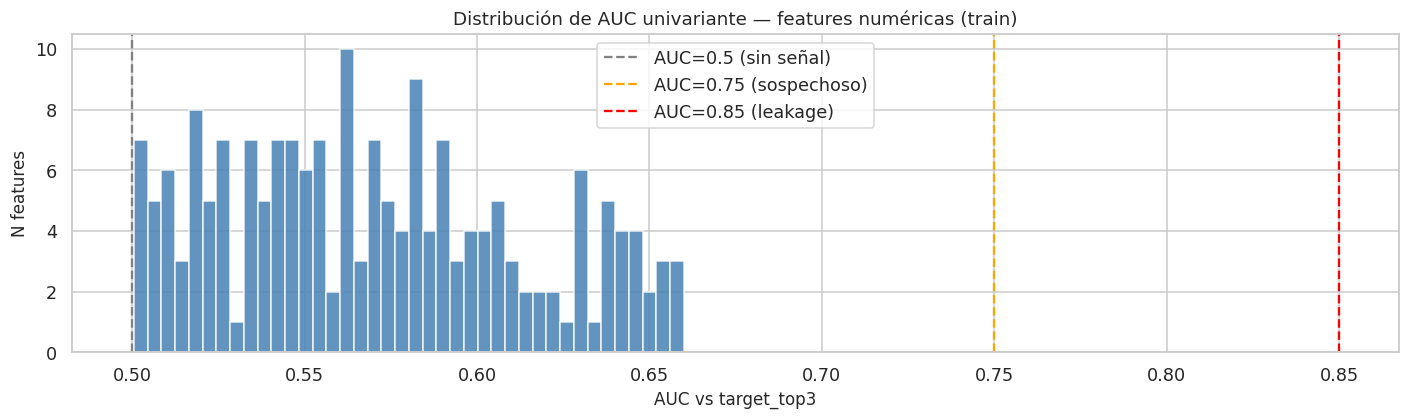

In [ ]:
POST_RACE_COLS = ['pos','odds_win','dist_al_anterior','distancia_al_anterior',
                  'target_top1','target_top3','target_pos','target_rank_label','race_has_winner']
META_COLS      = ['carrera_id','fecha','caballo_id','jinete_id','preparador_id',
                  'jornada_id','nombre','jinete_nombre','preparador_nombre',
                  'padre_id','madre_id','criador_id','padre___madre','carrera_nombre',
                  'numero','participantes']
POST_RACE_COLS = [c for c in POST_RACE_COLS if c in df.columns]
META_COLS      = [c for c in META_COLS      if c in df.columns]
EXCLUDE        = set(POST_RACE_COLS + META_COLS)

ALL_FEAT  = [c for c in df.columns if c not in EXCLUDE]
CAT_COLS  = [c for c in ALL_FEAT if df[c].dtype in ['object','category','bool']]
NUM_COLS  = [c for c in ALL_FEAT if c not in CAT_COLS]

target = df_train['target_top3'].astype(int).values

def feature_auc(s, y):
    valid = s.notna()
    if valid.sum() < 500: return np.nan
    s_v, y_v = s[valid].values, y[valid.values] if hasattr(y, '__getitem__') else y[valid]
    pos = s_v[y_v == 1]; neg = s_v[y_v == 0]
    if len(pos) < 30 or len(neg) < 30: return np.nan
    try:
        u, _ = mannwhitneyu(pos, neg, alternative='two-sided')
        auc = u / (len(pos) * len(neg))
        return max(auc, 1 - auc)
    except: return np.nan

leak_rows = []
for col in NUM_COLS:
    if df_train[col].nunique(dropna=True) < 3: continue
    auc = feature_auc(df_train[col], target)
    if not np.isnan(auc):
        leak_rows.append({'feature': col, 'auc': auc, 'n': df_train[col].notna().sum()})

leak_df = pd.DataFrame(leak_rows).sort_values('auc', ascending=False)

print(f'=== AUDITORÍA DE LEAKAGE (AUC univariante vs target_top3) ===')
print(f'Total features evaluadas: {len(leak_df)}')
print(f'AUC > 0.85 (leakage casi cierto):  {(leak_df.auc > 0.85).sum()}')
print(f'AUC > 0.75 (sospechoso):           {(leak_df.auc > 0.75).sum()}')
print(f'AUC > 0.65 (señal moderada):       {(leak_df.auc > 0.65).sum()}')
print(f'\nTop 15 features por AUC:')
display(leak_df.head(15))

# Plot distribución de AUCs
fig, ax = plt.subplots(figsize=(13, 4))
ax.hist(leak_df['auc'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', label='AUC=0.5 (sin señal)')
ax.axvline(0.75, color='orange', linestyle='--', label='AUC=0.75 (sospechoso)')
ax.axvline(0.85, color='red', linestyle='--', label='AUC=0.85 (leakage)')
ax.set_title('Distribución de AUC univariante — features numéricas (train)')
ax.set_xlabel('AUC vs target_top3'); ax.set_ylabel('N features')
ax.legend(); plt.tight_layout()
leak_df.to_csv(REPORTS / 'leakage_audit.csv', index=False)
print(f'\n✅ DIAGNÓSTICO: AUC máxima = {leak_df.auc.max():.4f} → no se detecta leakage individual')

---
## 4. Análisis Exploratorio Univariante

Participantes/carrera — min: 3, max: 20, media: 9.01


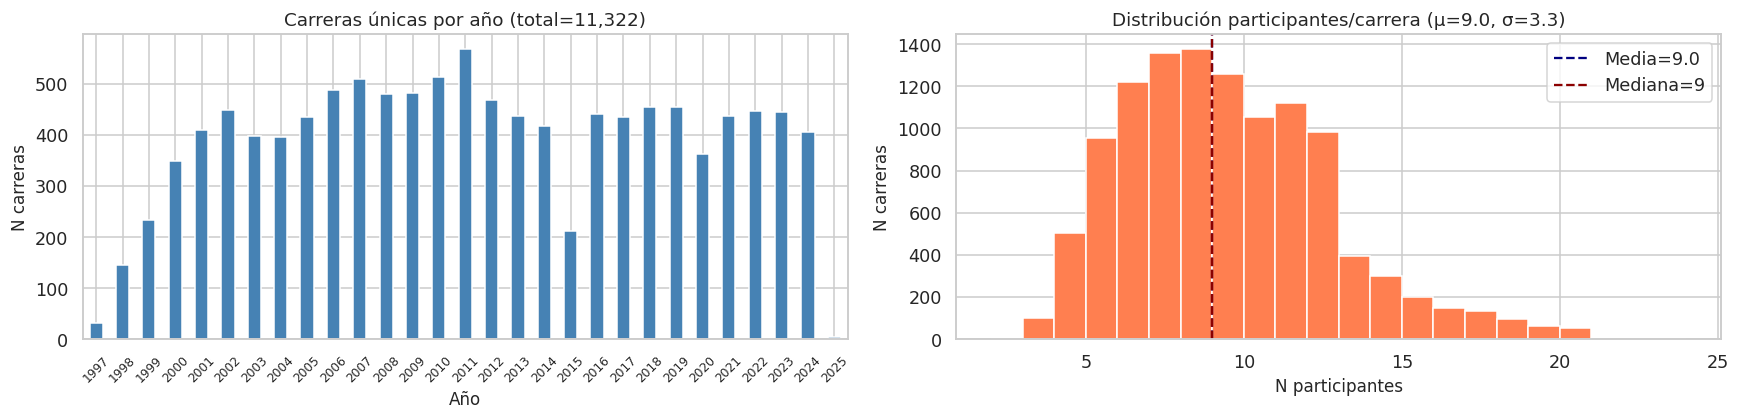

In [ ]:
# ── 4.1 Carreras por año + participantes por carrera ───────────────────
df['year'] = df.fecha.dt.year
races_per_year = df.groupby('year')['carrera_id'].nunique()
parts_per_race = df.groupby('carrera_id').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
races_per_year.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Carreras únicas por año (total={races_per_year.sum():,})')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('N carreras')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

axes[1].hist(parts_per_race, bins=range(2, 25), color='coral', edgecolor='white')
axes[1].axvline(parts_per_race.mean(), color='navy', linestyle='--',
                 label=f'Media={parts_per_race.mean():.1f}')
axes[1].axvline(parts_per_race.median(), color='darkred', linestyle='--',
                 label=f'Mediana={parts_per_race.median():.0f}')
axes[1].set_title(f'Distribución participantes/carrera (μ={parts_per_race.mean():.1f}, '
                  f'σ={parts_per_race.std():.1f})')
axes[1].set_xlabel('N participantes'); axes[1].set_ylabel('N carreras')
axes[1].legend()
plt.tight_layout()

print(f'Participantes/carrera — min: {parts_per_race.min()}, max: {parts_per_race.max()}, '
      f'media: {parts_per_race.mean():.2f}')

,n_carreras,n_filas,win_rate,top3_rate
hipodromo,,,,
La Zarzuela,4205,40840,0.1032,0.3090
San Sebastián,2185,20292,0.1077,0.3226
Mijas,1470,13610,0.1084,0.3243
GHA,1432,12236,0.1172,0.3506
Sanlúcar,651,5035,0.1303,0.3883
CA,533,3476,0.1536,0.4612
Pineda,397,3268,0.1218,0.3641
ANT,152,1431,0.1062,0.3187
CAN,130,820,0.1585,0.4768


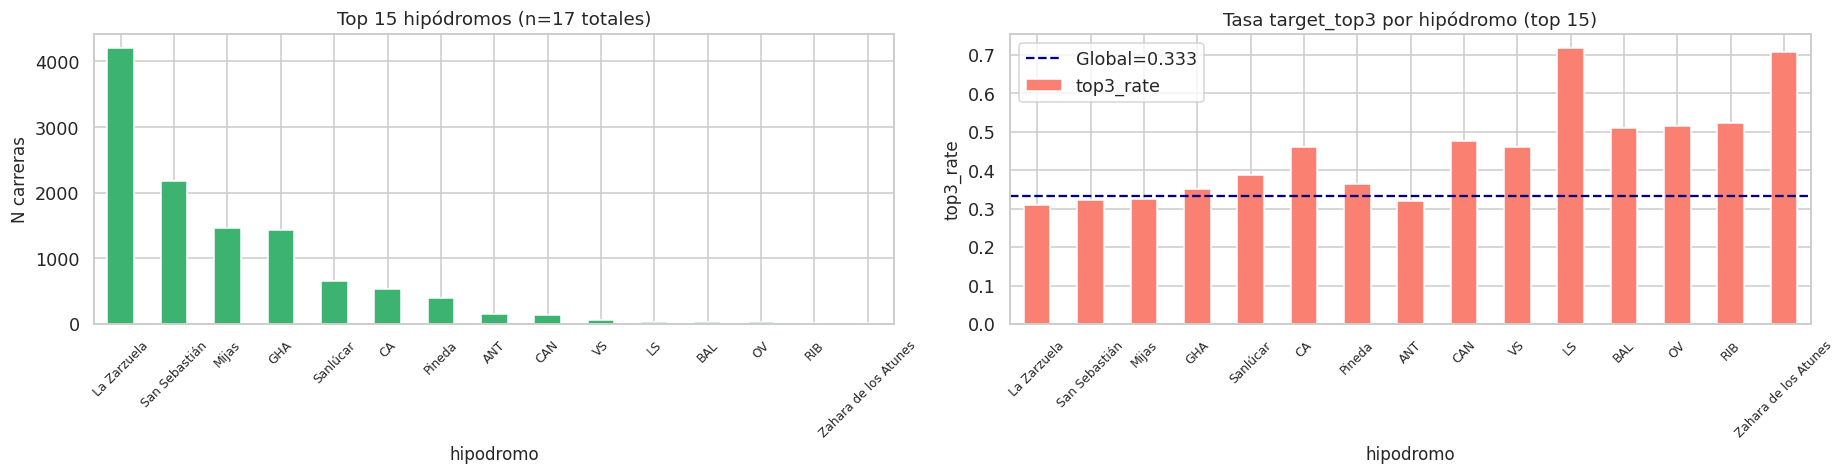

In [ ]:
# ── 4.2 Estructura por hipódromo ───────────────────────────────────────
hipo = df.groupby('hipodromo').agg(
    n_carreras=('carrera_id','nunique'),
    n_filas=('carrera_id','size'),
    win_rate=('target_top1','mean'),
    top3_rate=('target_top3','mean'),
).sort_values('n_carreras', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
hipo['n_carreras'].head(15).plot(kind='bar', ax=axes[0],
                                    color='mediumseagreen', edgecolor='white')
axes[0].set_title(f'Top 15 hipódromos (n={df.hipodromo.nunique()} totales)')
axes[0].set_ylabel('N carreras'); axes[0].tick_params(axis='x', rotation=45, labelsize=8)

hipo['top3_rate'].head(15).plot(kind='bar', ax=axes[1],
                                   color='salmon', edgecolor='white')
axes[1].axhline(df.target_top3.mean(), color='navy', linestyle='--',
                 label=f'Global={df.target_top3.mean():.3f}')
axes[1].set_title('Tasa target_top3 por hipódromo (top 15)')
axes[1].set_ylabel('top3_rate'); axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend()
plt.tight_layout()
display(hipo.head(10))

---
## 5. Calidad de Features: Nulos, Varianza y Cobertura

  Total features                      194
  Sin nulos                           34
  Con >50% nulos                      8
  Con >80% nulos                      8
  Cuasi-constantes (nunique<=3)       6
  Std<0.01                            4


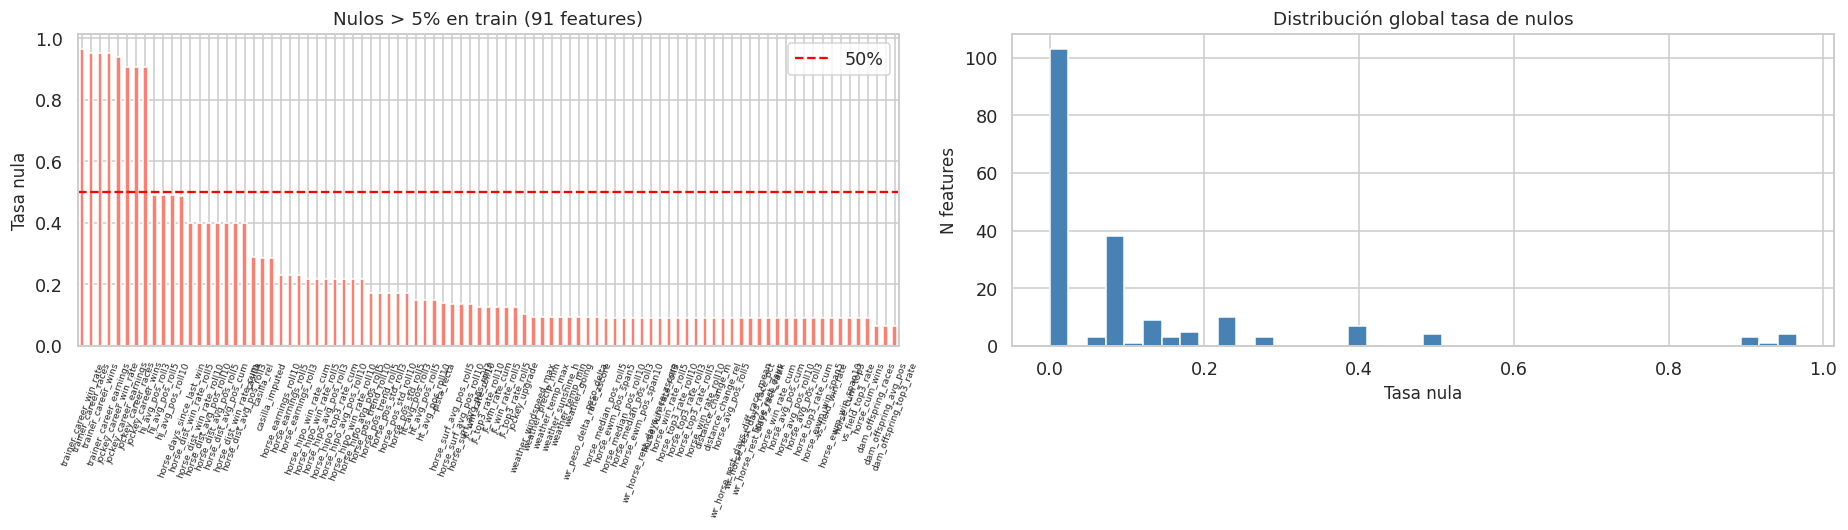

In [ ]:
null_rates = df_train[ALL_FEAT].isna().mean().sort_values(ascending=False)
var_stats = pd.DataFrame({
    'null_rate':  null_rates,
    'std':        df_train[ALL_FEAT].std(numeric_only=True),
    'nunique':    df_train[ALL_FEAT].nunique(),
})

summary_quality = {
    'Total features':                 len(ALL_FEAT),
    'Sin nulos':                      int((null_rates == 0).sum()),
    'Con >50% nulos':                 int((null_rates > 0.5).sum()),
    'Con >80% nulos':                 int((null_rates > 0.8).sum()),
    'Cuasi-constantes (nunique<=3)':  int((var_stats['nunique'] <= 3).sum()),
    'Std<0.01':                       int((var_stats['std'] < 0.01).sum()),
}
for k, v in summary_quality.items(): print(f'  {k:35s} {v}')

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
show = null_rates[null_rates > 0.05]
show.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', label='50%')
axes[0].set_title(f'Nulos > 5% en train ({len(show)} features)')
axes[0].set_ylabel('Tasa nula'); axes[0].legend()
axes[0].tick_params(axis='x', labelsize=6, rotation=70)

axes[1].hist(null_rates, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución global tasa de nulos')
axes[1].set_xlabel('Tasa nula'); axes[1].set_ylabel('N features')
plt.tight_layout()
var_stats.to_csv(REPORTS / 'feature_quality.csv')

In [ ]:
groups_null = {
    'horse_roll':  [c for c in NUM_COLS if c.startswith('horse_') and 'roll' in c],
    'horse_cum':   [c for c in NUM_COLS if c.startswith('horse_') and 'cum' in c],
    'jockey':      [c for c in NUM_COLS if c.startswith('jockey_')],
    'trainer':     [c for c in NUM_COLS if c.startswith('trainer_')],
    'hj_ht_jt':    [c for c in NUM_COLS if c.startswith(('hj_','ht_','jt_'))],
    'within_race': [c for c in NUM_COLS if c.startswith('wr_')],
    'weather':     [c for c in NUM_COLS if c.startswith('weather_')],
    'genealogy':   [c for c in NUM_COLS if c.startswith(('sire_','dam_'))],
    'race_meta':   [c for c in NUM_COLS if c in ['casilla','casilla_imputed','casilla_rel',
                                                    'distancia_m','field_n_runners',
                                                    'pista_recta','peso_delta']],
}
rows = []
for grp, cols in groups_null.items():
    if not cols: continue
    nr = df_train[cols].isna().mean()
    rows.append({'grupo': grp, 'n_features': len(cols),
                  'null_rate_media': nr.mean(),
                  'null_rate_max':   nr.max(),
                  'null_rate_min':   nr.min()})
groups_df = pd.DataFrame(rows).sort_values('null_rate_media', ascending=False)
print('Tasas de nulos por familia de features (train):')
display(groups_df.style.format({'null_rate_media':'{:.3f}',
                                 'null_rate_max':'{:.3f}',
                                 'null_rate_min':'{:.3f}'}))

Tasas de nulos por familia de features (train):


,grupo,n_features,null_rate_media,null_rate_max,null_rate_min
3,trainer,21,0.186,0.965,0.001
0,horse_roll,36,0.171,0.399,0.000
1,horse_cum,10,0.169,0.399,0.000
8,race_meta,7,0.156,0.288,0.000
2,jockey,26,0.155,0.939,0.001
4,hj_ht_jt,17,0.151,0.490,0.001
6,weather,6,0.096,0.096,0.096
7,genealogy,6,0.043,0.064,0.021
5,within_race,36,0.014,0.095,0.000


---
## 6. Covariate Shift entre Splits

Verificación crítica para evaluar si el modelo entrenado generalizará: ¿son las distribuciones de features estables entre train/val/test?

**Test estadístico**: Kolmogorov-Smirnov bilateral. La hipótesis nula H₀ es que las dos muestras provienen de la misma distribución.

=== SEVERIDAD DEL DRIFT (KS train vs test) ===
  baja      : 40 features
  moderada  : 47 features
  alta      : 69 features
  severa    : 31 features

Top 10 features con mayor drift train→test:


,feature,ks_train_val,p_tv,ks_train_test,p_tt,mean_train,mean_test,drift_severity
189,decade,0.645,0.000e+00,1.000,0.000e+00,2002.965,2020.000,severa
121,wr_jockey_n_prev_races_race_mean,0.655,0.000e+00,0.666,0.000e+00,527.654,1384.919,severa
126,wr_trainer_n_prev_races_race_mean,0.443,0.000e+00,0.619,0.000e+00,546.737,1276.405,severa
47,trainer_cum_earnings,0.322,0.000e+00,0.414,0.000e+00,346114.338,1883664.050,severa
59,jockey_career_races,0.347,2.341e-144,0.364,1.198e-136,6.079,11.315,severa
122,wr_jockey_n_prev_races_diff_race_mean,0.275,0.000e+00,0.354,0.000e+00,-0.000,-0.000,severa
111,wr_horse_cum_earnings_race_mean,0.272,0.000e+00,0.342,0.000e+00,5887.986,13535.519,severa
61,jockey_career_earnings,0.286,1.369e-97,0.340,2.319e-119,4954.975,15091.583,severa
45,jockey_earnings_roll10,0.213,0.000e+00,0.332,0.000e+00,7285.945,15054.848,severa
46,trainer_n_prev_races,0.232,0.000e+00,0.319,0.000e+00,546.865,1276.405,severa


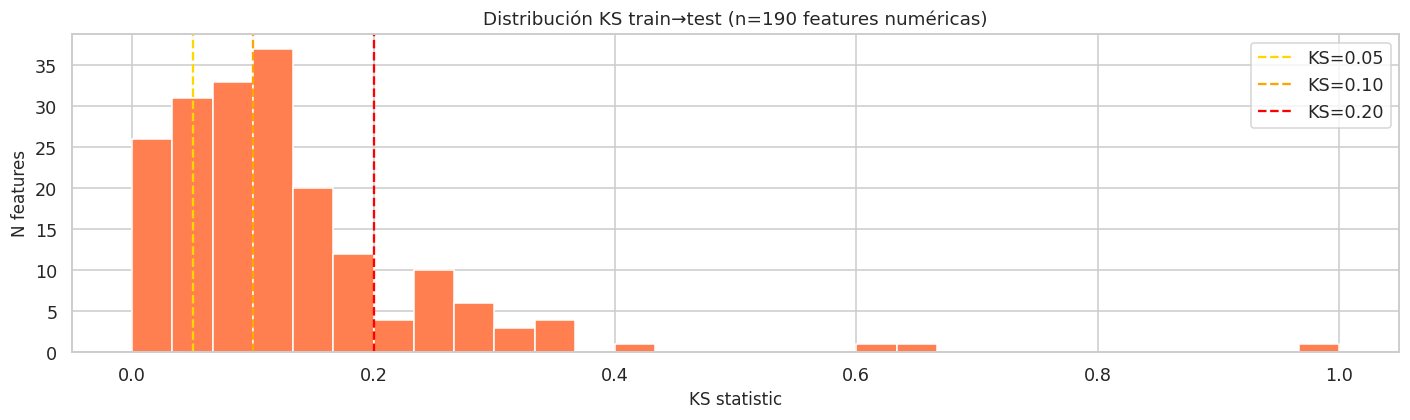

In [ ]:
shift_rows = []
for col in NUM_COLS:
    a = df_train[col].dropna()
    b = df_val[col].dropna()
    c = df_test[col].dropna()
    if len(a) < 200 or len(c) < 50: continue
    try:
        ks_tv, p_tv = ks_2samp(a, b)
        ks_tt, p_tt = ks_2samp(a, c)
        shift_rows.append({'feature': col, 'ks_train_val': ks_tv, 'p_tv': p_tv,
                            'ks_train_test': ks_tt, 'p_tt': p_tt,
                            'mean_train': a.mean(), 'mean_test': c.mean()})
    except: continue

shift_df = pd.DataFrame(shift_rows).sort_values('ks_train_test', ascending=False)
shift_df['drift_severity'] = pd.cut(shift_df['ks_train_test'],
                                       bins=[0, 0.05, 0.10, 0.20, 1.0],
                                       labels=['baja','moderada','alta','severa'])

drift_summary = shift_df['drift_severity'].value_counts().reindex(['baja','moderada','alta','severa']).fillna(0)
print('=== SEVERIDAD DEL DRIFT (KS train vs test) ===')
for k, v in drift_summary.items(): print(f'  {k:10s}: {int(v)} features')

print(f'\nTop 10 features con mayor drift train→test:')
display(shift_df.head(10).style.format({'ks_train_val':'{:.3f}','ks_train_test':'{:.3f}',
                                          'p_tv':'{:.3e}','p_tt':'{:.3e}',
                                          'mean_train':'{:.3f}','mean_test':'{:.3f}'}))

fig, ax = plt.subplots(figsize=(13, 4))
ax.hist(shift_df['ks_train_test'], bins=30, color='coral', edgecolor='white')
ax.axvline(0.05, color='gold', linestyle='--', label='KS=0.05')
ax.axvline(0.10, color='orange', linestyle='--', label='KS=0.10')
ax.axvline(0.20, color='red',    linestyle='--', label='KS=0.20')
ax.set_title(f'Distribución KS train→test (n={len(shift_df)} features numéricas)')
ax.set_xlabel('KS statistic'); ax.set_ylabel('N features')
ax.legend(); plt.tight_layout()
shift_df.to_csv(REPORTS / 'covariate_shift.csv', index=False)

---
## 7. Poder Predictivo Univariante

Top 25 features por AUC univariante (target_top1):


,feature,auc_top1,auc_top3,r_top1,null_rate
82,horse_hipo_avg_pos_roll3,0.6501,0.6600,-0.101,0.219
84,horse_hipo_avg_pos_roll5,0.6488,0.6582,-0.101,0.219
86,horse_hipo_avg_pos_roll10,0.6478,0.6577,-0.100,0.219
152,horse_ewm_pos_span5,0.6464,0.6535,-0.153,0.092
89,horse_surf_avg_pos_roll3,0.6441,0.6539,-0.098,0.138
154,horse_ewm_pos_span10,0.6436,0.6513,-0.151,0.092
91,horse_surf_avg_pos_roll10,0.6425,0.6515,-0.102,0.138
90,horse_surf_avg_pos_roll5,0.6420,0.6524,-0.101,0.138
131,vs_field_top3_rate,0.6384,0.6320,+0.151,0.092
88,horse_hipo_top3_rate_cum,0.6363,0.6412,+0.157,0.219


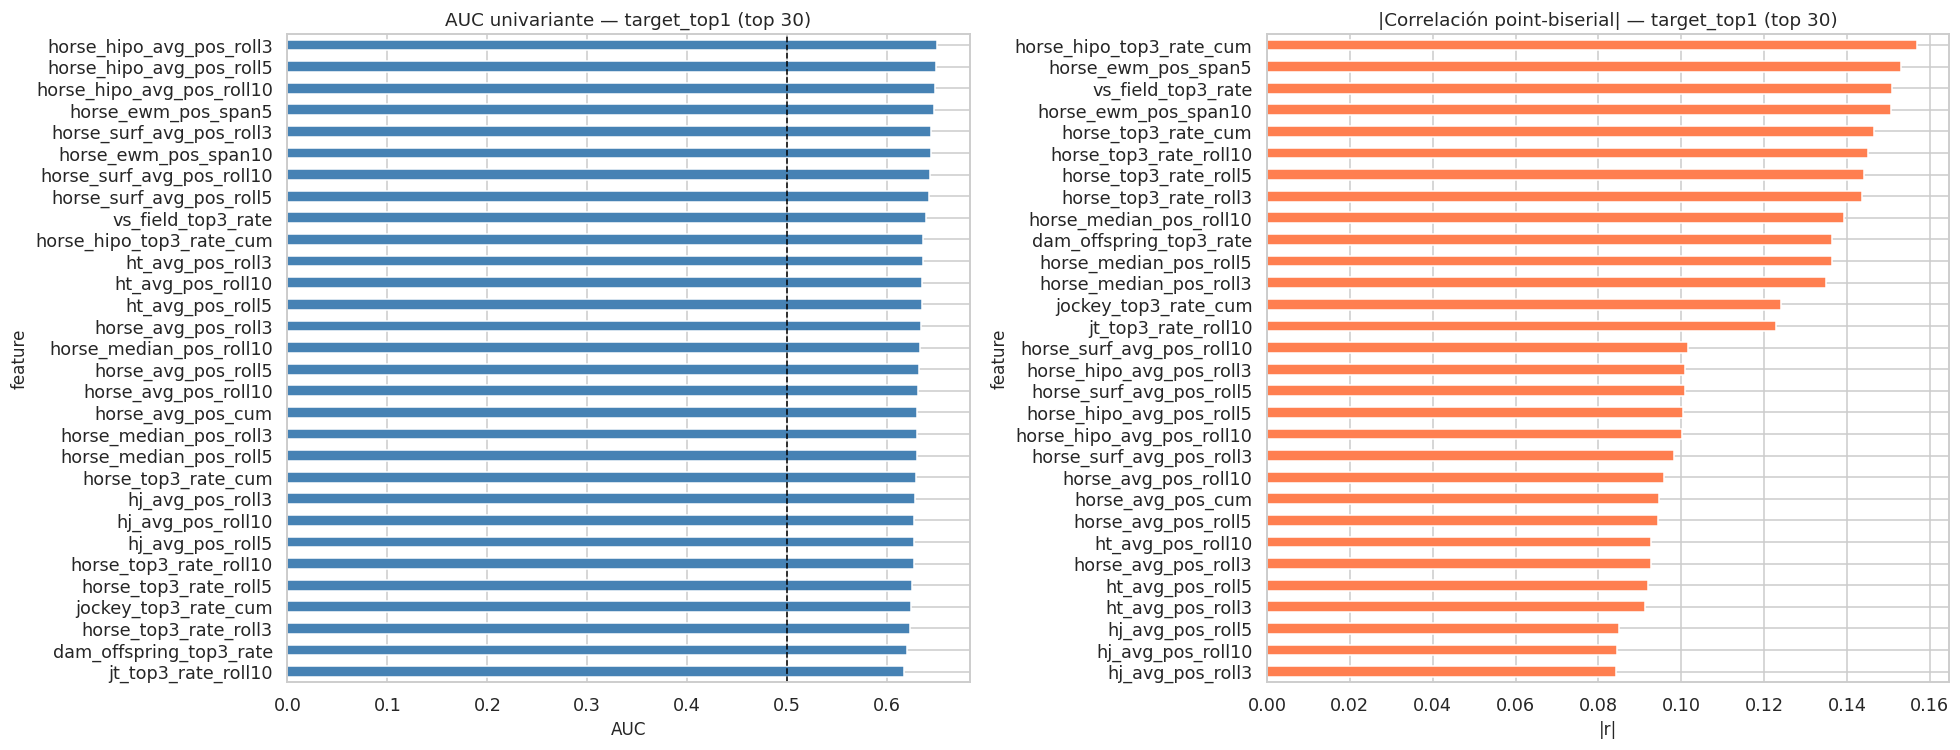

In [ ]:
y_top1 = df_train['target_top1'].astype(int).values
y_top3 = df_train['target_top3'].astype(int).values

rows = []
for col in NUM_COLS:
    if df_train[col].nunique() < 3: continue
    a1 = feature_auc(df_train[col], y_top1)
    a3 = feature_auc(df_train[col], y_top3)
    valid = df_train[[col,'target_top1']].dropna()
    try:    r1 = pointbiserialr(valid['target_top1'], valid[col]).statistic
    except: r1 = np.nan
    rows.append({'feature': col, 'auc_top1': a1, 'auc_top3': a3, 'r_top1': r1,
                  'null_rate': df_train[col].isna().mean()})

power = pd.DataFrame(rows).sort_values('auc_top1', ascending=False, na_position='last')
print(f'Top 25 features por AUC univariante (target_top1):')
display(power.head(25).style.format({'auc_top1':'{:.4f}','auc_top3':'{:.4f}',
                                       'r_top1':'{:+.3f}','null_rate':'{:.3f}'}))

top30 = power.head(30).set_index('feature')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top30['auc_top1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', lw=1)
axes[0].set_title('AUC univariante — target_top1 (top 30)')
axes[0].set_xlabel('AUC')

top30['r_top1'].abs().sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('|Correlación point-biserial| — target_top1 (top 30)')
axes[1].set_xlabel('|r|')
plt.tight_layout()
power.to_csv(REPORTS / 'feature_univariate_power.csv', index=False)

---
## 8. Estabilidad Temporal del Poder Predictivo

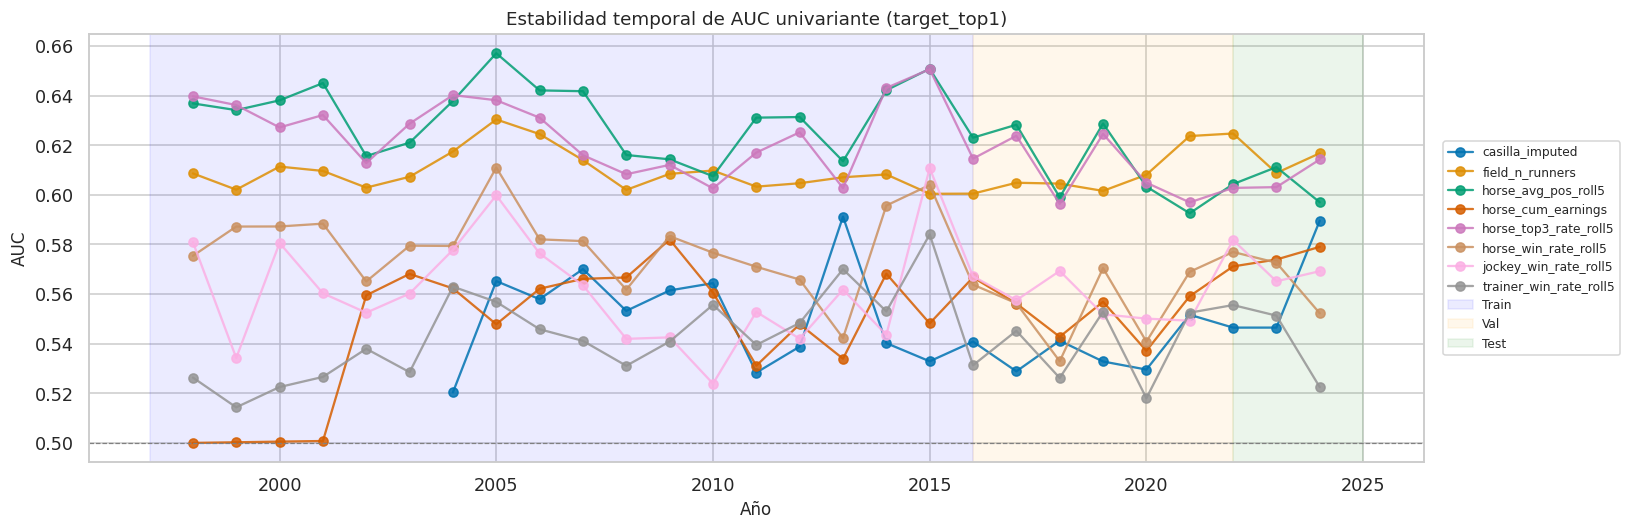

In [ ]:
key_feats = ['horse_win_rate_roll5', 'horse_top3_rate_roll5', 'horse_avg_pos_roll5',
             'jockey_win_rate_roll5','trainer_win_rate_roll5','horse_cum_earnings',
             'field_n_runners','casilla_imputed']
key_feats = [f for f in key_feats if f in df.columns]

rows = []
for yr in sorted(df.year.unique()):
    if yr < 1998: continue
    yrdf = df[df.year == yr]
    if len(yrdf) < 200: continue
    y_yr = yrdf['target_top1'].values
    for c in key_feats:
        a = feature_auc(yrdf[c], y_yr)
        rows.append({'year': yr, 'feature': c, 'auc': a})
stab = pd.DataFrame(rows).dropna()

fig, ax = plt.subplots(figsize=(15, 5))
for f, g in stab.groupby('feature'):
    g = g.sort_values('year')
    ax.plot(g['year'], g['auc'], marker='o', label=f, alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', lw=0.8)
ax.axvspan(df_train.fecha.min().year, df_train.fecha.max().year, alpha=0.08, color='blue', label='Train')
ax.axvspan(df_val.fecha.min().year,   df_val.fecha.max().year,   alpha=0.08, color='orange', label='Val')
ax.axvspan(df_test.fecha.min().year,  df_test.fecha.max().year,  alpha=0.08, color='green', label='Test')
ax.set_title('Estabilidad temporal de AUC univariante (target_top1)')
ax.set_xlabel('Año'); ax.set_ylabel('AUC')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
stab.to_csv(REPORTS / 'feature_temporal_stability.csv', index=False)

---
## 9. Distribuciones, Monotonía y Correlaciones

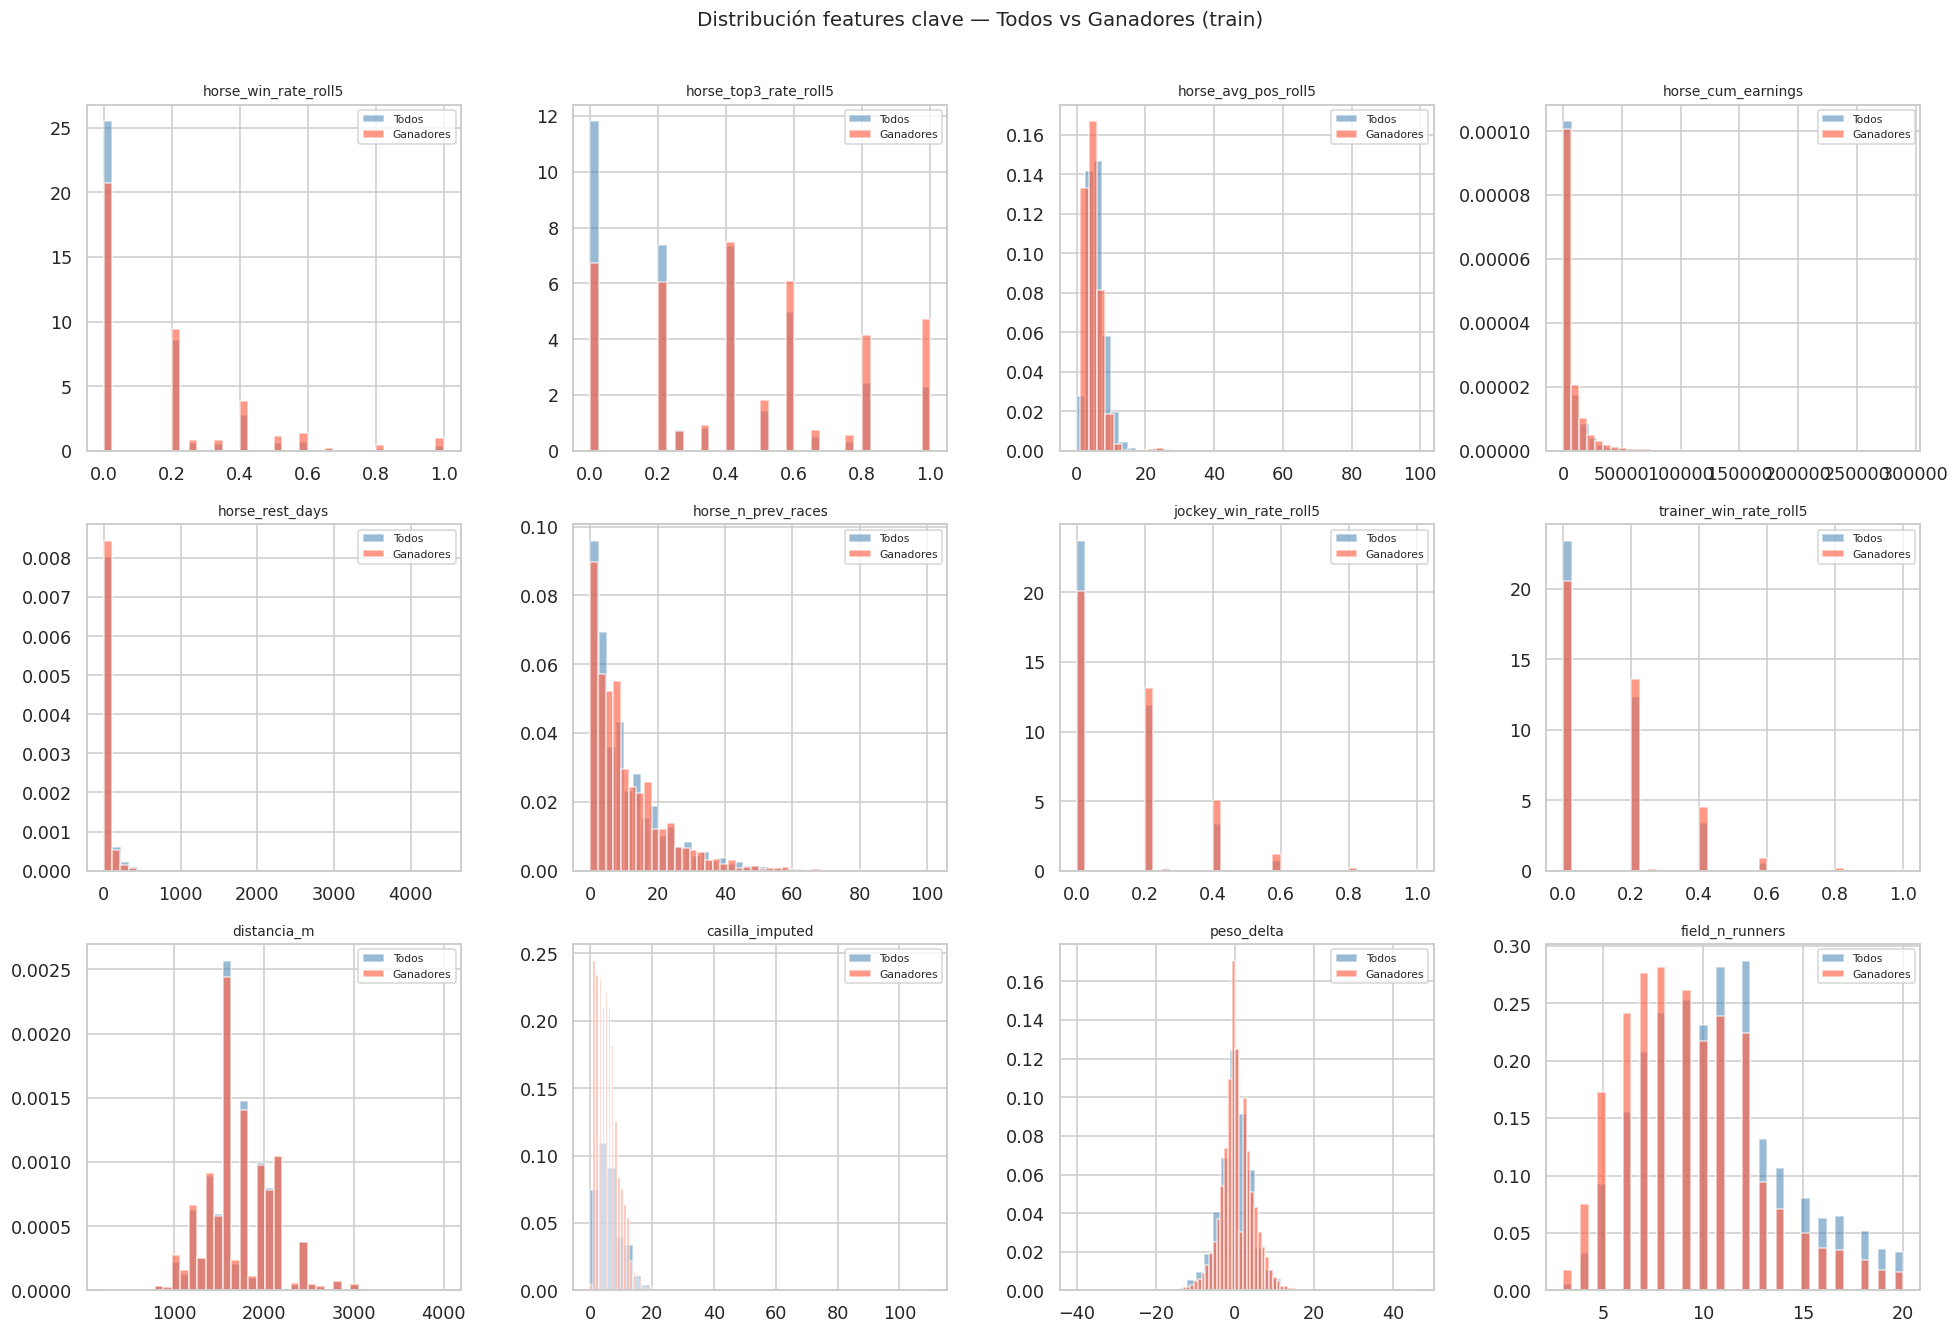

In [ ]:
plot_feats = ['horse_win_rate_roll5','horse_top3_rate_roll5','horse_avg_pos_roll5',
              'horse_cum_earnings','horse_rest_days','horse_n_prev_races',
              'jockey_win_rate_roll5','trainer_win_rate_roll5','distancia_m',
              'casilla_imputed','peso_delta','field_n_runners']
plot_feats = [f for f in plot_feats if f in df_train.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(plot_feats):
    ax = axes[i]
    a = df_train[col].dropna()
    w = df_train.loc[df_train.target_top1 == 1, col].dropna()
    if len(w) == 0: continue
    ax.hist(a, bins=40, alpha=0.55, color='steelblue', label='Todos', density=True)
    ax.hist(w, bins=40, alpha=0.65, color='tomato',    label='Ganadores', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribución features clave — Todos vs Ganadores (train)', y=1.01, fontsize=13)
plt.tight_layout()

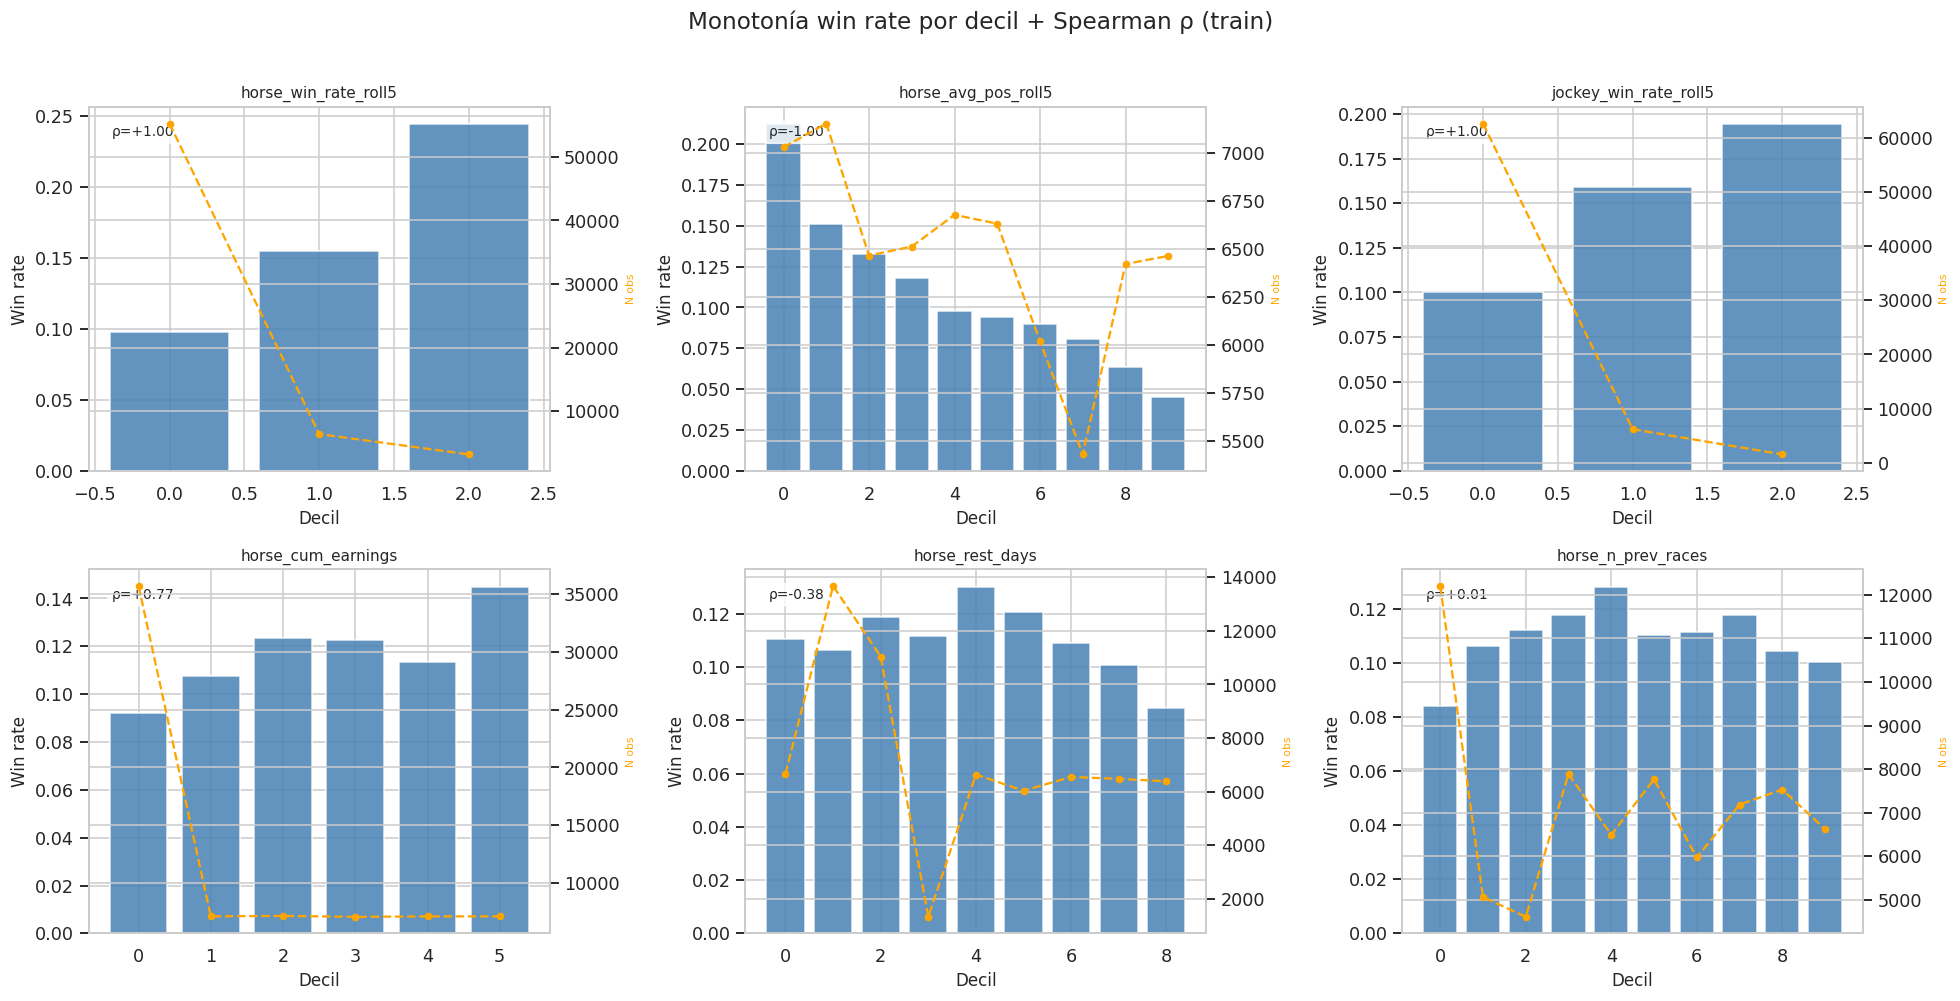

In [ ]:
mono = ['horse_win_rate_roll5','horse_avg_pos_roll5','jockey_win_rate_roll5',
        'horse_cum_earnings','horse_rest_days','horse_n_prev_races']
mono = [f for f in mono if f in df_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(mono):
    valid = df_train[[col,'target_top1']].dropna().copy()
    valid['bin'] = pd.qcut(valid[col], q=10, duplicates='drop')
    binned = valid.groupby('bin', observed=True)['target_top1'].agg(['mean','count']).reset_index()
    axes[i].bar(range(len(binned)), binned['mean'], color='steelblue', alpha=0.85, edgecolor='white')
    ax2 = axes[i].twinx()
    ax2.plot(range(len(binned)), binned['count'], 'o--', color='orange', markersize=4)
    ax2.set_ylabel('N obs', fontsize=7, color='orange')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Win rate'); axes[i].set_xlabel('Decil')
    rho = spearmanr(range(len(binned)), binned['mean']).statistic
    axes[i].text(0.05, 0.95, f'ρ={rho:+.2f}', transform=axes[i].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.suptitle('Monotonía win rate por decil + Spearman ρ (train)', y=1.01)
plt.tight_layout()

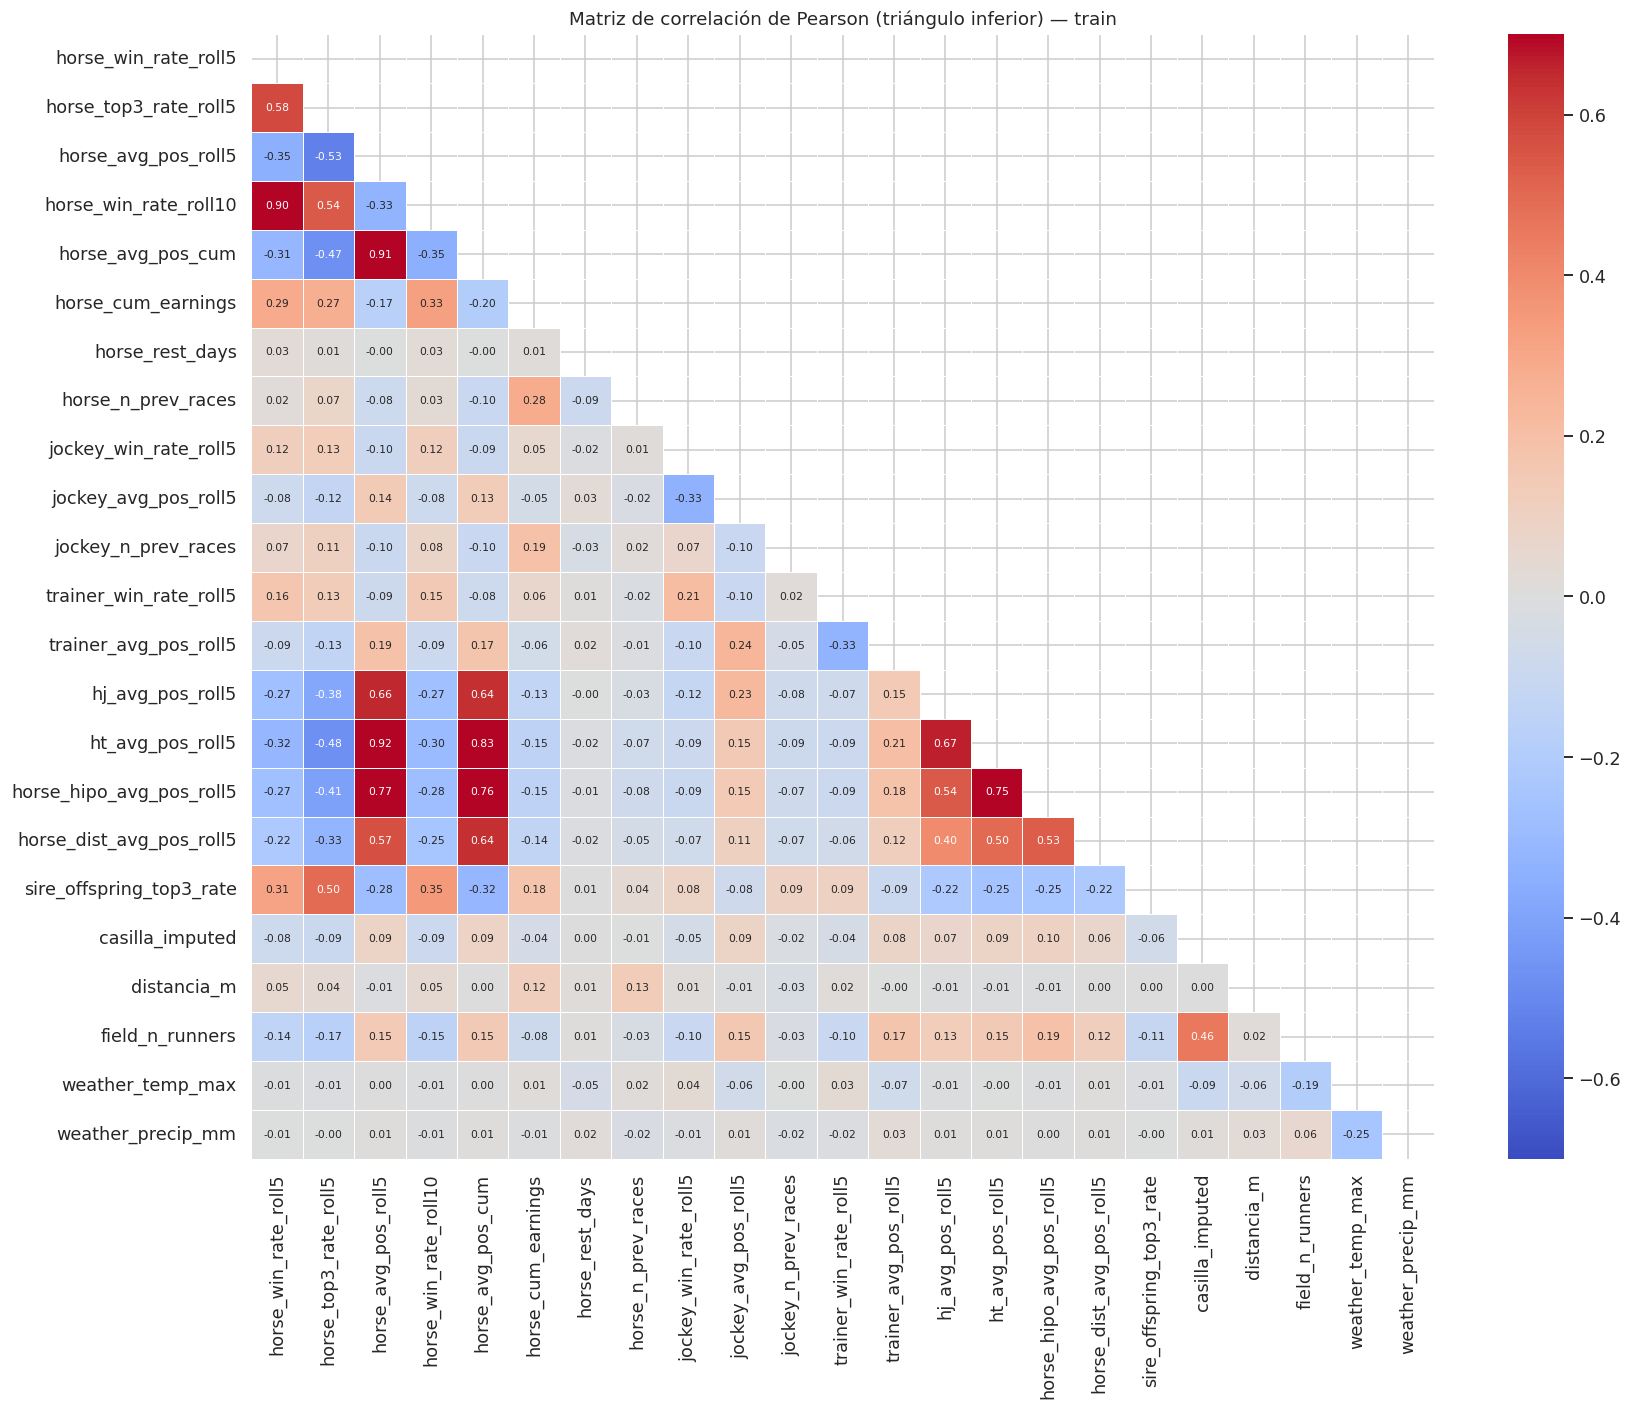

In [ ]:
corr_feats = ['horse_win_rate_roll5','horse_top3_rate_roll5','horse_avg_pos_roll5',
              'horse_win_rate_roll10','horse_avg_pos_cum','horse_cum_earnings',
              'horse_rest_days','horse_n_prev_races',
              'jockey_win_rate_roll5','jockey_avg_pos_roll5','jockey_n_prev_races',
              'trainer_win_rate_roll5','trainer_avg_pos_roll5',
              'hj_avg_pos_roll5','ht_avg_pos_roll5',
              'horse_hipo_avg_pos_roll5','horse_dist_avg_pos_roll5',
              'sire_offspring_top3_rate','casilla_imputed','distancia_m','field_n_runners',
              'weather_temp_max','weather_precip_mm']
corr_feats = [c for c in corr_feats if c in df_train.columns]
corr = df_train[corr_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
             linewidths=0.4, ax=ax, annot_kws={'size':7}, vmin=-0.7, vmax=0.7)
ax.set_title('Matriz de correlación de Pearson (triángulo inferior) — train')
plt.tight_layout()
fig.savefig(REPORTS / 'feature_correlation_matrix.png', dpi=130, bbox_inches='tight')

---
## 10. Preprocesamiento Reproducible y Persistencia de Artefactos

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

TARGET_COL = 'target_top3'
GROUP_COL  = 'carrera_id'

# Label encoders (fit en concat de todos los splits para cubrir todas las categorías)
label_encoders = {}
df_concat = pd.concat([df_train, df_val, df_test], ignore_index=True)
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(df_concat[col].astype('string').fillna('__NA__'))
    label_encoders[col] = le
    mapping = {v: i for i, v in enumerate(le.classes_)}
    for sp in [df_train, df_val, df_test]:
        sp[f'{col}_enc'] = sp[col].astype('string').fillna('__NA__').map(mapping).fillna(-1).astype(int)

enc_cols = [f'{c}_enc' for c in CAT_COLS]
FEATURE_COLS = [c for c in (NUM_COLS + enc_cols) if c in df_train.columns]

X_train = df_train[FEATURE_COLS]
X_val   = df_val[FEATURE_COLS]
X_test  = df_test[FEATURE_COLS]
y_train = df_train[TARGET_COL].astype(int).values
y_val   = df_val[TARGET_COL].astype(int).values
y_test  = df_test[TARGET_COL].astype(int).values

# Imputer y Scaler (fit SOLO con train)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Features totales para modelado: {len(FEATURE_COLS)}')
print(f'  Numéricas:           {len(NUM_COLS)}')
print(f'  Categóricas (enc):   {len(enc_cols)} → {CAT_COLS}')
print(f'\nShapes: X_train={X_train_imp.shape} | X_val={X_val_imp.shape} | X_test={X_test_imp.shape}')
print(f'Balance (target_top3): train={y_train.mean():.4f} | val={y_val.mean():.4f} | test={y_test.mean():.4f}')

# Persistir artefactos
with open(MODELS_DIR / 'imputer.pkl', 'wb') as f: pickle.dump(imputer, f)
with open(MODELS_DIR / 'scaler.pkl',  'wb') as f: pickle.dump(scaler,  f)
with open(MODELS_DIR / 'label_encoders.pkl', 'wb') as f: pickle.dump(label_encoders, f)

feature_meta = {
    'created_at':       datetime.now().isoformat(timespec='seconds'),
    'numpy':            np.__version__,
    'pandas':           pd.__version__,
    'TARGET_COL':       TARGET_COL,
    'GROUP_COL':        GROUP_COL,
    'POST_RACE_COLS':   POST_RACE_COLS,
    'META_COLS':        META_COLS,
    'CAT_COLS':         CAT_COLS,
    'NUM_COLS':         NUM_COLS,
    'enc_cols':         enc_cols,
    'FEATURE_COLS':     FEATURE_COLS,
    'split_strategy':   'temporal_chronological_70_20_10',
    'date_train_min':   str(df_train.fecha.min().date()),
    'date_train_max':   str(df_train.fecha.max().date()),
    'date_val_min':     str(df_val.fecha.min().date()),
    'date_val_max':     str(df_val.fecha.max().date()),
    'date_test_min':    str(df_test.fecha.min().date()),
    'date_test_max':    str(df_test.fecha.max().date()),
    'n_train':          len(df_train),
    'n_val':            len(df_val),
    'n_test':           len(df_test),
}
with open(MODELS_DIR / 'feature_meta.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print(f'\nArtefactos guardados en: {MODELS_DIR}')
for f in ['imputer.pkl','scaler.pkl','label_encoders.pkl','feature_meta.json']:
    print(f'  {f}')

Features totales para modelado: 194
  Numéricas:           190
  Categóricas (enc):   4 → ['condiciones', 'pista', 'hipodromo', 'caballo']

Shapes: X_train=(71336, 194) | X_val=(20414, 194) | X_test=(10208, 194)
Balance (target_top3): train=0.3214 | val=0.3518 | test=0.3780

Artefactos guardados en: /content/data/models
  imputer.pkl
  scaler.pkl
  label_encoders.pkl
  feature_meta.json


---
## 11. Resumen Ejecutivo y Checks Finales

In [ ]:
checks = {
    'train.fecha.max() < val.fecha.min()':  df_train.fecha.max() < df_val.fecha.min(),
    'val.fecha.max()   < test.fecha.min()': df_val.fecha.max()   < df_test.fecha.min(),
    'carreras únicas disjuntas (tr-vl)':    set(df_train.carrera_id).isdisjoint(set(df_val.carrera_id)),
    'carreras únicas disjuntas (vl-te)':    set(df_val.carrera_id).isdisjoint(set(df_test.carrera_id)),
    'sin features con AUC>0.85 (no leakage)': (leak_df.auc > 0.85).sum() == 0,
    'fechas dataset >= 1997':               df.fecha.min() >= pd.Timestamp('1997-01-01', tz='UTC'),
    'carrera_id <= 11926':                  df.carrera_id.max() <= 11926,
    'pos no nula en train':                 df_train['pos'].notna().mean() > 0.95,
}
checks_df = pd.DataFrame([{'check': k, 'pasa': '✅' if v else '❌'} for k, v in checks.items()])
print('=== INVARIANTES VALIDADAS ===')
display(checks_df)

print(f'\n=== HASH SHA-1 DE PARQUETS (reproducibilidad) ===')
for f in ['master_clean.parquet','split_train_temporal.parquet',
          'split_val_temporal.parquet','split_test_temporal.parquet']:
    p = PROCESSED / f
    h = hashlib.sha1(p.read_bytes()).hexdigest()[:16]
    sz = p.stat().st_size / 1e6
    print(f'  {f:40s} SHA1={h}  ({sz:.1f} MB)')

print('\n✅ EDA Y PREPROCESAMIENTO COMPLETOS — listo para modelado en notebook 04.')

=== INVARIANTES VALIDADAS ===


,check,pasa
0,train.fecha.max() < val.fecha.min(),✅
1,val.fecha.max() < test.fecha.min(),✅
2,carreras únicas disjuntas (tr-vl),✅
3,carreras únicas disjuntas (vl-te),✅
4,sin features con AUC>0.85 (no leakage),✅
5,fechas dataset >= 1997,✅
6,carrera_id <= 11926,✅
7,pos no nula en train,✅



=== HASH SHA-1 DE PARQUETS (reproducibilidad) ===
  master_clean.parquet                     SHA1=a0213e3f223bf9b9  (33.2 MB)
  split_train_temporal.parquet             SHA1=6e40410aa001566c  (22.8 MB)
  split_val_temporal.parquet               SHA1=47ec35bf873a2fb2  (7.3 MB)
  split_test_temporal.parquet              SHA1=fde7f22a65fb70c1  (3.8 MB)

✅ EDA Y PREPROCESAMIENTO COMPLETOS — listo para modelado en notebook 04.


## Análisis adicional de fiabilidad y relaciones entre variables

Este bloque complementa la EDA con pruebas orientadas a defender la calidad del dataset final: modelabilidad efectiva, auditoría de `peso`, señales de posible leakage, estabilidad temporal de la tasa de podio, matriz de correlaciones robusta y asociación entre familias de variables y el target top-3. El objetivo no es maximizar complejidad gráfica, sino aportar evidencia clara sobre la fiabilidad del conjunto de datos y las relaciones más relevantes antes del modelado.


Dataset maestro: (101958, 217)
Subconjunto modelable: (101958, 217)


,columna,nulos_pct,n_unicos,dtype
0,fecha,0.0000,2028,"datetime64[us, UTC]"
1,caballo_id,0.0000,9246,Int64
2,target_top3,0.0000,2,Int64
3,target_top1,0.0000,2,Int64
4,pos,0.0000,47,Int64
5,peso,0.0016,217,float64
6,odds_win,0.3175,1306,float64


,valor
n,101792.0000
nulos,166.0000
ceros,0.0000
fuera_35_75kg,6.0000
p01,50.0000
mediana,57.0000
p99,67.0000
max,98.0000


Features numéricas candidatas: 191
Features con cobertura < 60%: 12


,cobertura
trainer_career_win_rate,0.0475
trainer_career_wins,0.0563
trainer_career_earnings,0.0563
trainer_career_races,0.0563
jockey_career_win_rate,0.0729
jockey_career_races,0.0957
jockey_career_earnings,0.0957
jockey_career_wins,0.0957
hj_avg_pos_roll5,0.5158
hj_avg_pos_roll3,0.5158


,feature,auc_univariante,auc_abs,cobertura
82,horse_hipo_avg_pos_roll3,0.3464,0.6536,0.7886
84,horse_hipo_avg_pos_roll5,0.3476,0.6524,0.7886
86,horse_hipo_avg_pos_roll10,0.3479,0.6521,0.7886
89,horse_surf_avg_pos_roll3,0.3485,0.6515,0.8618
136,field_n_runners,0.3492,0.6508,1.0000
2,participantes_programa,0.3492,0.6508,1.0000
90,horse_surf_avg_pos_roll5,0.3493,0.6507,0.8618
97,wr_distancia_m_race_pct,0.6506,0.6506,0.9987
91,horse_surf_avg_pos_roll10,0.3498,0.6502,0.8618
152,horse_ewm_pos_span5,0.3520,0.6480,0.9089


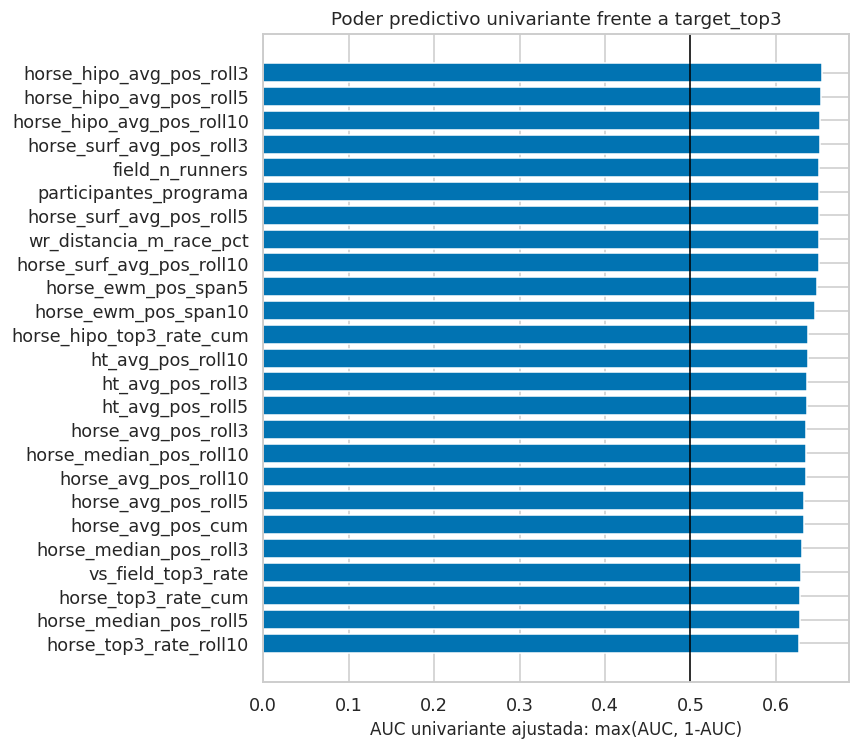

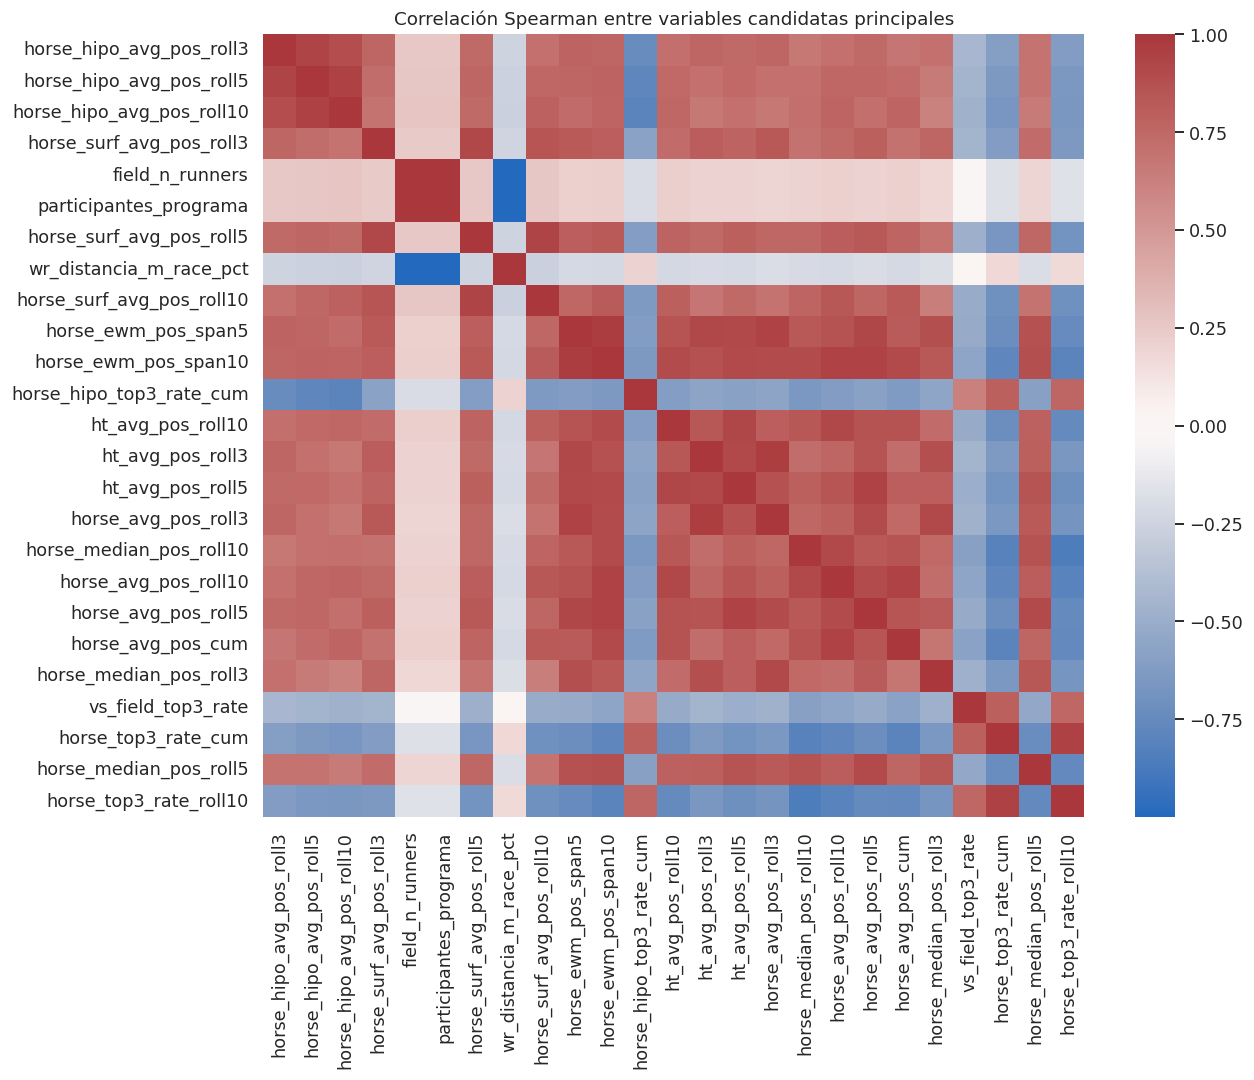

,mean,count
year,,
1997,0.2526,380
1998,0.2850,1530
1999,0.3096,2264
2000,0.3231,3250
2001,0.3361,3657
2002,0.3125,4307
2003,0.3327,3595
2004,0.3356,3543
2005,0.3659,3572


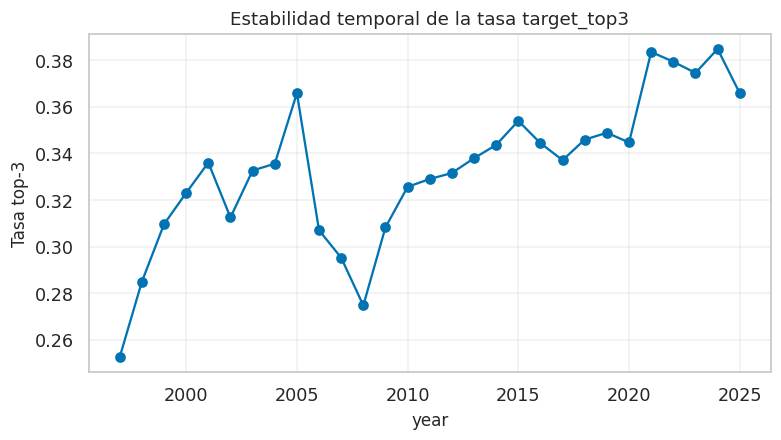

In [ ]:
# Auditoría adicional de calidad, fiabilidad y relaciones entre variables
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

try:
    df
except NameError:
    df = load_final_dataset()

modelable = prepare_modelable_dataset(df)
print('Dataset maestro:', df.shape)
print('Subconjunto modelable:', modelable.shape)

quality_rows = []
for col in [DATE_COL, RACE_ID_COL, HORSE_ID_COL, TARGET_COL, WIN_TARGET_COL, POSITION_COL, 'peso', 'odds_win']:
    if col in df.columns:
        quality_rows.append({
            'columna': col,
            'nulos_pct': float(df[col].isna().mean()),
            'n_unicos': int(df[col].nunique(dropna=True)),
            'dtype': str(df[col].dtype),
        })
quality = pd.DataFrame(quality_rows)
display(quality)

if RACE_ID_COL in modelable.columns and TARGET_COL in modelable.columns:
    race_targets = modelable.groupby(RACE_ID_COL)[TARGET_COL].agg(['sum','count'])
    display(race_targets['sum'].value_counts().sort_index().rename('carreras').to_frame())
    print('Carreras modelables:', race_targets.shape[0])
    print('Carreras con top3 exacto:', int((race_targets['sum'] == 3).sum()))

if 'peso' in df.columns:
    peso = pd.to_numeric(df['peso'], errors='coerce')
    peso_diag = pd.Series({
        'n': peso.notna().sum(),
        'nulos': peso.isna().sum(),
        'ceros': (peso == 0).sum(),
        'fuera_35_75kg': ((peso < 35) | (peso > 75)).sum(),
        'p01': peso.quantile(.01),
        'mediana': peso.median(),
        'p99': peso.quantile(.99),
        'max': peso.max(),
    })
    display(peso_diag.to_frame('valor'))

feature_cols = get_feature_columns(modelable, include_odds=False, include_quarantine=False)
num = modelable[feature_cols + [TARGET_COL]].select_dtypes(include=[np.number]).replace([np.inf,-np.inf], np.nan)
coverage = num.notna().mean().sort_values()
low_coverage = coverage[coverage < .60].to_frame('cobertura')
print('Features numéricas candidatas:', len(feature_cols))
print('Features con cobertura < 60%:', low_coverage.shape[0])
display(low_coverage.head(20))

auc_rows = []
for c in feature_cols:
    s = pd.to_numeric(modelable[c], errors='coerce')
    valid = s.notna() & modelable[TARGET_COL].notna()
    if valid.sum() < 500 or modelable.loc[valid, TARGET_COL].nunique() < 2 or s[valid].nunique() < 3:
        continue
    try:
        auc = roc_auc_score(modelable.loc[valid, TARGET_COL], s[valid])
        auc_rows.append({'feature': c, 'auc_univariante': auc, 'auc_abs': max(auc, 1-auc), 'cobertura': valid.mean()})
    except Exception:
        pass
auc_df = pd.DataFrame(auc_rows).sort_values('auc_abs', ascending=False)
display(auc_df.head(25))

if not auc_df.empty:
    plt.figure(figsize=(8, max(4, min(10, .28*min(25, len(auc_df))))))
    plot_df = auc_df.head(25).sort_values('auc_abs')
    plt.barh(plot_df['feature'], plot_df['auc_abs'])
    plt.axvline(.5, color='black', linewidth=1)
    plt.title('Poder predictivo univariante frente a target_top3')
    plt.xlabel('AUC univariante ajustada: max(AUC, 1-AUC)')
    plt.tight_layout()
    plt.show()

corr_candidates = auc_df.head(25)['feature'].tolist() if not auc_df.empty else feature_cols[:25]
if corr_candidates:
    corr = modelable[corr_candidates].corr(method='spearman', min_periods=500)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='vlag', center=0, square=False)
    plt.title('Correlación Spearman entre variables candidatas principales')
    plt.tight_layout()
    plt.show()

if DATE_COL in modelable.columns and TARGET_COL in modelable.columns:
    tmp = modelable.assign(year=modelable[DATE_COL].dt.year).groupby('year')[TARGET_COL].agg(['mean','count'])
    display(tmp)
    ax = tmp['mean'].plot(marker='o', figsize=(8,4), title='Estabilidad temporal de la tasa target_top3')
    ax.set_ylabel('Tasa top-3')
    ax.grid(alpha=.3)
    plt.show()
